# IMPORT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,784 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

# 시작

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# 0. 설정
# =========================================================
FILE_PATH   = "/content/태림_외부변수_통합_최종v6.xlsx"
OUTPUT_PATH = "/content/태림_품명별_LAG분석_최종_v7.xlsx"

DEMAND_SHEET  = '태림_외부변수_매핑'
FEATURE_SHEET = '외부변수_전체_LAG용'

TARGET    = "FIRM_RATIO"
MAX_LAG   = 16
ALPHA     = 0.05
MIN_R     = 0.20
VIF_THR   = 10.0
REP_MODES = ["level", "diff", "pct"]

# =========================================================
# 1. 그룹 정의
# =========================================================
#   LAG 안정성 테스트 결과 금속 그룹이 3개 품명에서 불안정 판정
#     그룹 내 r 최대 1개만 최종 선택

# PCA 적용 그룹 (안정성 검증 통과한 것만)
PCA_GROUPS = {
    '유가':     ['Brent_Oil', 'WTI_Oil'],
    '해상운임': ['BDI', 'SCFI', 'CCFI'],
    '주가':     ['SP500', 'BOVESPA', 'KOSPI'],
}
PCA_FEATURE_MAP = {
    '유가':     'OIL_FACTOR',
    '해상운임': 'SHIP_FACTOR',
    '주가':     'STOCK_FACTOR',
}

# 개별 변수 그룹
INDIVIDUAL_GROUPS = {
    '환율':       ['BRL_USD'],
    '금속':       ['Steel_Price', 'Aluminum_Price', 'Copper_Price', 'IronOre_Price'],
    '공급망압박': ['GSCPI'],
    '제조업경기': ['US_PMI', 'Brazil_IndProd'],
    '자동차판매': ['BR_AutoSales', 'US_AutoSales'],
    '브라질금융': ['SELIC_Rate', 'Brazil_CPI'],
    '반도체경기': ['SOX'],
}

ALL_EXT_COLS = (
    [v for g in PCA_GROUPS.values() for v in g] +
    [v for g in INDIVIDUAL_GROUPS.values() for v in g]
)
PCA_FACTOR_COLS   = list(PCA_FEATURE_MAP.values())
INDIVIDUAL_COLS   = [v for g in INDIVIDUAL_GROUPS.values() for v in g]
FINAL_BASE_FEATURES = PCA_FACTOR_COLS + INDIVIDUAL_COLS

FEATURE_TO_GROUP = {}
for g, cols in PCA_GROUPS.items():
    for c in cols:
        FEATURE_TO_GROUP[c] = g
for g, cols in INDIVIDUAL_GROUPS.items():
    for c in cols:
        FEATURE_TO_GROUP[c] = g
for g, fname in PCA_FEATURE_MAP.items():
    FEATURE_TO_GROUP[fname] = g

print("PCA 그룹:", {k: v for k, v in PCA_FEATURE_MAP.items()})
print("개별 그룹:", {k: list(v) for k, v in INDIVIDUAL_GROUPS.items()})
print(f"총 후보 피처: {len(FINAL_BASE_FEATURES)}개 → {FINAL_BASE_FEATURES}")

# =========================================================
# 2. 컬럼명 정리 매핑
# =========================================================
COL_RENAME = {
    'Firm/\nForecast':              'Firm_Forecast',
    'Shipping\nInst':               'Shipping_Inst',
    'Shipped\nInvoice':             'Shipped_Invoice',
    'BRL/USD\n(헤알/달러)':          'BRL_USD',
    'KRW/USD\n(원/달러)':            'KRW_USD',
    'KRW/BRL\n(원/헤알)\n★계산값':   'KRW_BRL',
    '철강가격\n(PPI지수\n월별)':      'Steel_Price',
    '알루미늄\n(USD/MT\n월별)':       'Aluminum_Price',
    '구리\n(USD/MT\n월별)':           'Copper_Price',
    '철광석\n(USD/MT\n월별)':         'IronOre_Price',
    '브렌트유\n(USD/배럴)':           'Brent_Oil',
    'WTI유\n(USD/배럴)':              'WTI_Oil',
    'BDI\n(포인트)':                  'BDI',
    'SCFI\n(상하이운임\n지수)':        'SCFI',
    'CCFI\n(중국운임\n지수)':          'CCFI',
    '미국PMI\n(제조업\n월별)':         'US_PMI',
    '브라질\n산업생산\n(월별)':         'Brazil_IndProd',
    'SP500\n(일별)':                  'SP500',
    'BOVESPA\n(일별)':                'BOVESPA',
    'SOX\n(일별)':                    'SOX',
    'KOSPI\n(일별)':                  'KOSPI',
    '자동차\n판매량(TOTALSA)':         'US_AutoSales',
}

MONTH_MAP = {
    'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
    'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12,
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12,
}

# =========================================================
# 3. 데이터 로드
# =========================================================
demand_raw  = pd.read_excel(FILE_PATH, sheet_name=DEMAND_SHEET, header=0)
feature_raw = pd.read_excel(FILE_PATH, sheet_name=FEATURE_SHEET, header=0)

demand_raw  = demand_raw.rename(columns=COL_RENAME)
feature_raw = feature_raw.rename(columns=COL_RENAME)

for c in ['Quantity'] + ALL_EXT_COLS:
    if c in demand_raw.columns:
        demand_raw[c] = pd.to_numeric(demand_raw[c], errors='coerce')
for c in ALL_EXT_COLS:
    if c in feature_raw.columns:
        feature_raw[c] = pd.to_numeric(feature_raw[c], errors='coerce')

print(f"[수요 시트] {demand_raw.shape}")
print(f"[외부변수 시트] {feature_raw.shape}")

missing = [c for c in ALL_EXT_COLS if c not in feature_raw.columns]
if missing:
    print(f"Sheet2에서 못 찾은 컬럼: {missing}")
else:
    print(" Sheet2 컬럼 전부 확인")

# =========================================================
# 4. 날짜 처리
# =========================================================
demand_raw['Month_num'] = (
    demand_raw['Month'].astype(str).str.strip().str[:3].str.title().map(MONTH_MAP)
)
demand_raw['Date'] = pd.to_datetime(
    dict(
        year=pd.to_numeric(demand_raw['Year'],       errors='coerce'),
        month=pd.to_numeric(demand_raw['Month_num'], errors='coerce'),
        day=pd.to_numeric(demand_raw['Day'],         errors='coerce'),
    ),
    errors='coerce',
)
demand_raw = demand_raw.dropna(subset=['Date']).copy()
demand_raw['Week'] = demand_raw['Date'].dt.to_period('W-MON').dt.start_time

feature_raw['Date'] = pd.to_datetime(feature_raw['Date'], errors='coerce')
mask = feature_raw['Date'].isna()
if mask.any():
    num = pd.to_numeric(feature_raw.loc[mask, 'Date'], errors='coerce')
    feature_raw.loc[mask, 'Date'] = pd.to_datetime(
        num, unit='D', origin='1899-12-30', errors='coerce'
    )
feature_raw = feature_raw.dropna(subset=['Date']).copy()
feature_raw['Week'] = feature_raw['Date'].dt.to_period('W-MON').dt.start_time

PN_LIST = demand_raw['ZF_PN'].dropna().unique()
print(f"품명 {len(PN_LIST)}개: {list(PN_LIST)}")

# =========================================================
# 5. 주 단위 집계
# =========================================================
avail_ext = [c for c in ALL_EXT_COLS if c in feature_raw.columns]
feature_weekly = (
    feature_raw.groupby('Week', as_index=False)[avail_ext]
    .mean()
    .sort_values('Week')
    .reset_index(drop=True)
)
print(f"[외부변수 주단위] {feature_weekly.shape}")
print(f"Week 범위: {feature_weekly['Week'].min()} ~ {feature_weekly['Week'].max()}")

def make_weekly_target(df, pn):
    sub = df[df['ZF_PN'] == pn].copy()
    records = []
    for week, g in sub.groupby('Week'):
        firm  = g.loc[g['Firm_Forecast'] == 'FIRM',     'Quantity'].sum()
        fc    = g.loc[g['Firm_Forecast'] == 'FORECAST', 'Quantity'].sum()
        total = firm + fc
        records.append({
            'Week':       week,
            'FIRM':       firm,
            'FORECAST':   fc,
            'Total_Qty':  total,
            'FIRM_RATIO': firm / total if total > 0 else np.nan,
        })
    return pd.DataFrame(records).sort_values('Week').reset_index(drop=True)

weekly_dict = {}
merge_check = []

for pn in PN_LIST:
    tgt    = make_weekly_target(demand_raw, pn)
    merged = pd.merge(feature_weekly, tgt, on='Week', how='left') \
               .sort_values('Week').reset_index(drop=True)
    miss_r = merged[[TARGET]].isna().mean().values[0]
    weekly_dict[pn] = merged
    merge_check.append({
        'PN':              pn,
        'feature_weeks':   len(feature_weekly),
        'target_weeks':    len(tgt),
        'merged_weeks':    len(merged),
        'target_missing':  f"{miss_r:.1%}",
    })
    overlap = len(set(tgt['Week']) & set(feature_weekly['Week']))
    print(f"  {pn}: 타깃 {len(tgt)}주 / 외부변수 {len(feature_weekly)}주 / 겹침 {overlap}주")

merge_check_df = pd.DataFrame(merge_check)

# =========================================================
# 6. 보조 함수
# =========================================================
def make_pca_factor(df, cols, group_name=''):
    sub   = df[cols].copy()
    valid = sub.dropna()

    if len(valid) < 8:
        print(f"    [{group_name}] 유효 샘플 부족({len(valid)}) → NaN")
        return pd.Series(index=df.index, dtype=float), np.nan

    if valid.shape[1] == 1:
        z = (valid.iloc[:,0] - valid.iloc[:,0].mean()) / (valid.iloc[:,0].std(ddof=0) + 1e-9)
        print(f"    [{group_name}] 변수 1개 → 표준화")
        return z.reindex(df.index), 1.0

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(valid)
    pca      = PCA(n_components=1)
    comp     = pca.fit_transform(X_scaled).flatten()
    explained = pca.explained_variance_ratio_[0]
    flag     = "" if explained >= 0.6 else " 낮음"
    print(f"    [{group_name}] PCA 설명분산: {explained:.1%} {flag}")

    return pd.Series(comp, index=valid.index).reindex(df.index), explained

def add_pca_factors(df):
    out  = df.copy()
    info = []
    for group_name, cols in PCA_GROUPS.items():
        valid_cols  = [c for c in cols if c in out.columns]
        factor_name = PCA_FEATURE_MAP[group_name]
        factor, exp = make_pca_factor(out, valid_cols, group_name)
        out[factor_name] = factor
        info.append({
            '그룹':    group_name,
            'factor명': factor_name,
            '원본변수': ', '.join(valid_cols),
            '설명분산': exp,
        })
    return out, pd.DataFrame(info)

def add_representations(df, cols):
    out = df.copy()
    for col in cols:
        if col not in out.columns:
            continue
        out[f'{col}__level'] = out[col]
        out[f'{col}__diff']  = out[col].diff()
        out[f'{col}__pct']   = out[col].pct_change()
    return out

def calc_best_corr(y, x, alpha=0.05):
    tmp = pd.concat([y, x], axis=1).dropna()
    if len(tmp) < 8 or tmp.iloc[:,0].nunique() < 2 or tmp.iloc[:,1].nunique() < 2:
        return np.nan, None, len(tmp)

    try:    p_corr, p_pval = stats.pearsonr(tmp.iloc[:,0], tmp.iloc[:,1])
    except: p_corr, p_pval = np.nan, np.nan

    try:    s_corr, s_pval = stats.spearmanr(tmp.iloc[:,0], tmp.iloc[:,1])
    except: s_corr, s_pval = np.nan, np.nan

    p_ok = p_corr if pd.notna(p_pval) and p_pval < alpha else np.nan
    s_ok = s_corr if pd.notna(s_pval) and s_pval < alpha else np.nan

    if   pd.isna(p_ok) and pd.isna(s_ok): return np.nan, None, len(tmp)
    elif pd.isna(p_ok):                    return s_ok, 'Spearman', len(tmp)
    elif pd.isna(s_ok):                    return p_ok, 'Pearson',  len(tmp)
    else:
        return (p_ok, 'Pearson', len(tmp)) if abs(p_ok) >= abs(s_ok) \
               else (s_ok, 'Spearman', len(tmp))

def run_lag_analysis(weekly_df, target_col, base_features, rep_modes, max_lag=16, alpha=0.05):
    y        = weekly_df[target_col]
    rows     = []
    lag_rows = []

    for base_var in base_features:
        best_row = None

        for rep in rep_modes:
            rep_col = f'{base_var}__{rep}'
            if rep_col not in weekly_df.columns:
                continue

            for lag in range(1, max_lag + 1):
                x = weekly_df[rep_col].shift(lag)
                r, method, n_valid = calc_best_corr(y, x, alpha=alpha)

                lag_rows.append({
                    '변수':           base_var,
                    '그룹':           FEATURE_TO_GROUP.get(base_var),
                    'representation': rep,
                    'rep_col':        rep_col,
                    'lag':            lag,
                    'r':              r,
                    '방법':           method,
                    'n_valid':        n_valid,
                })

                if pd.isna(r):
                    continue

                cand = {
                    '변수':           base_var,
                    '그룹':           FEATURE_TO_GROUP.get(base_var),
                    'representation': rep,
                    'rep_col':        rep_col,
                    '최적_lag':       lag,
                    'r':              float(r),
                    '방법':           method,
                    '방향':           '양(+)' if r > 0 else '음(-)',
                    'n_valid':        n_valid,
                }

                if best_row is None or abs(cand['r']) > abs(best_row['r']):
                    best_row = cand

        rows.append(best_row if best_row is not None else {
            '변수':           base_var,
            '그룹':           FEATURE_TO_GROUP.get(base_var),
            'representation': None,
            'rep_col':        None,
            '최적_lag':       np.nan,
            'r':              np.nan,
            '방법':           None,
            '방향':           None,
            'n_valid':        np.nan,
        })

    summary          = pd.DataFrame(rows)
    summary['r_abs'] = summary['r'].abs()
    summary          = summary.sort_values('r_abs', ascending=False) \
                               .drop(columns='r_abs').reset_index(drop=True)
    return summary, pd.DataFrame(lag_rows)

def select_group_representatives(summary_df, min_r=0.2):
    """
    PCA 그룹: factor 1개 고정
    개별 그룹: 그룹 내 r 절댓값 최대 변수 1개 선택
     금속 그룹: Steel/Aluminum/Copper/IronOre 중 품명별로 가장 r 높은 1개 선택
    """
    selected = []

    # PCA 그룹 → factor 1개씩
    for group_name, factor_name in PCA_FEATURE_MAP.items():
        cand = summary_df[
            (summary_df['변수'] == factor_name) &
            summary_df['representation'].notna() &
            summary_df['최적_lag'].notna() &
            (summary_df['r'].abs() >= min_r)
        ].copy()
        if len(cand) > 0:
            selected.append(cand.iloc[[cand['r'].abs().argmax()]])

    # 개별 그룹 → 그룹별 r 최대 1개
    for group_name, group_vars in INDIVIDUAL_GROUPS.items():
        cand = summary_df[
            (summary_df['그룹'] == group_name) &
            summary_df['representation'].notna() &
            summary_df['최적_lag'].notna() &
            (summary_df['r'].abs() >= min_r)
        ].copy()
        if len(cand) > 0:
            selected.append(cand.iloc[[cand['r'].abs().argmax()]])

    return pd.concat(selected, ignore_index=True) if selected else pd.DataFrame()

def calc_vif(df, cols):
    X = df[cols].dropna().astype(float)
    if len(cols) < 2 or len(X) < len(cols) + 2:
        return pd.Series(dtype=float)
    vals = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    return pd.Series(vals, index=cols)

def select_by_vif(df, cols, threshold=10, verbose=True):
    remaining = cols.copy()
    while len(remaining) > 1:
        X = df[remaining].dropna()
        if len(X) < len(remaining) + 2:
            break
        vifs = calc_vif(df, remaining)
        if len(vifs) == 0 or vifs.max() < threshold:
            break
        drop_col = vifs.idxmax()
        if verbose:
            print(f"    VIF 제거: {drop_col:40s} VIF={vifs[drop_col]:.2f}")
        remaining.remove(drop_col)
    return remaining

# =========================================================
# 7. 품명별 분석 실행
# =========================================================
pca_info_by_pn       = {}
lag_summary_by_pn    = {}
lag_detail_by_pn     = {}
group_selected_by_pn = {}
vif_by_pn            = {}
final_dataset_by_pn  = {}

for pn in PN_LIST:
    print(f"\n{'='*75}")
    print(f"[{pn}]")
    print(f"{'='*75}")

    w = weekly_dict[pn].copy()
    w = w.dropna(subset=[TARGET]).copy().reset_index(drop=True)
    w = w[~w[avail_ext].isna().all(axis=1)].copy().reset_index(drop=True)
    print(f"  유효 주수: {len(w)}주")

    # PCA factor 생성 (유가/해상운임/주가만)
    print("\n  [PCA factor 생성]")
    w, pca_info = add_pca_factors(w)
    pca_info_by_pn[pn] = pca_info.copy()

    # representation 추가
    actual_base = [f for f in FINAL_BASE_FEATURES if f in w.columns]
    w = add_representations(w, actual_base)

    # LAG 분석
    print("\n  [LAG 분석 실행 중...]")
    summary, lag_detail = run_lag_analysis(
        weekly_df=w,
        target_col=TARGET,
        base_features=actual_base,
        rep_modes=REP_MODES,
        max_lag=MAX_LAG,
        alpha=ALPHA,
    )
    lag_summary_by_pn[pn] = summary.copy()
    lag_detail_by_pn[pn]  = lag_detail.copy()

    show = ['그룹','변수','representation','최적_lag','r','방법','방향']
    print(f"\n  LAG 분석 결과 (상위 10개):")
    print(summary.head(10)[show].to_string(index=False))

    # ★ 금속 그룹 선택 결과 별도 출력 (어떤 금속 변수가 선택됐는지 확인용)
    metal_cand = summary[summary['그룹'] == '금속'][show]
    if len(metal_cand) > 0:
        print(f"\n  [금속 그룹 후보] (그룹 내 r 최대 1개 선택)")
        print(metal_cand.to_string(index=False))

    # 그룹 대표 선택
    selected = select_group_representatives(summary, min_r=MIN_R)
    group_selected_by_pn[pn] = selected.copy()

    print(f"\n  [그룹 대표 선택] {len(selected)}개")
    if len(selected) > 0:
        print(selected[show].to_string(index=False))
    else:
        print("  없음")
        final_dataset_by_pn[pn] = pd.DataFrame()
        vif_by_pn[pn]           = pd.DataFrame()
        continue

    # lag feature 생성
    selected             = selected.copy()
    selected['최적_lag'] = pd.to_numeric(selected['최적_lag'], errors='coerce')
    selected             = selected[
        selected['최적_lag'].notna() & (selected['최적_lag'] >= 1)
    ].copy()
    selected['최적_lag']    = selected['최적_lag'].astype(int)
    selected['생성피처명']  = selected.apply(
        lambda r: f"{r['rep_col']}_lag{r['최적_lag']}", axis=1
    )

    w_model = w[['Week', TARGET, 'FIRM', 'FORECAST', 'Total_Qty']].copy()
    for _, row in selected.iterrows():
        w_model[row['생성피처명']] = w[row['rep_col']].shift(row['최적_lag'])

    feat_cols   = selected['생성피처명'].tolist()
    w_valid_vif = w_model[[TARGET] + feat_cols].dropna()
    print(f"\n  유효 샘플: {len(w_valid_vif)}주 | 피처: {len(feat_cols)}개")

    # VIF 확인 및 제거
    vif_df = pd.DataFrame()
    if len(feat_cols) > 1 and len(w_valid_vif) >= len(feat_cols) + 3:
        vif_vals = calc_vif(w_valid_vif, feat_cols)
        vif_df   = (
            pd.DataFrame({'생성피처명': vif_vals.index, 'VIF': vif_vals.values})
            .sort_values('VIF', ascending=False)
            .reset_index(drop=True)
        )

        print(f"\n  [VIF 확인]")
        for _, row in vif_df.iterrows():
            flag = " ← 제거" if row['VIF'] >= VIF_THR else ""
            print(f"    {row['생성피처명']:45s} VIF={row['VIF']:8.2f}{flag}")

        if vif_vals.max() >= VIF_THR:
            print(f"\n  [VIF 제거 시작]")
            kept      = select_by_vif(w_valid_vif, feat_cols, threshold=VIF_THR)
            selected  = selected[selected['생성피처명'].isin(kept)].copy().reset_index(drop=True)
            feat_cols = selected['생성피처명'].tolist()
        else:
            print(f"  → 모두 VIF < {VIF_THR}")
    else:
        print("  → 단일 피처 또는 샘플 부족 → VIF 스킵")

    vif_by_pn[pn] = vif_df.copy()

    # 최종 데이터셋
    keep_cols = ['Week', TARGET, 'FIRM', 'FORECAST', 'Total_Qty'] + feat_cols
    final_ds  = w_model[keep_cols].dropna().reset_index(drop=True)
    final_dataset_by_pn[pn] = final_ds.copy()

    if len(feat_cols) > 1:
        vif_final = calc_vif(final_ds, feat_cols)
        print(f"\n  [최종 VIF]")
        for col, v in vif_final.items():
            flag = " " if v >= VIF_THR else " "
            print(f" {col:45s} VIF={v:.2f}{flag}")

    print(f"\n 최종 피처 {len(feat_cols)}개 | 학습 샘플 {len(final_ds)}주")
    print(f"     {feat_cols}")

print("\n\n전체 분석 완료")

# =========================================================
# 8. 전체 요약 & 피벗 비교표
# =========================================================
def concat_by_pn(d):
    rows = [df_.assign(PN=pn) for pn, df_ in d.items()
            if df_ is not None and len(df_) > 0]
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

pca_info_all    = concat_by_pn(pca_info_by_pn)
lag_summary_all = concat_by_pn(lag_summary_by_pn)
selected_all    = concat_by_pn(group_selected_by_pn)
vif_all         = concat_by_pn(vif_by_pn)
lag_detail_all  = concat_by_pn(lag_detail_by_pn)

print("=" * 75)
print("▶ 품명별 최종 선택 변수 요약")
print("=" * 75)

show = ['그룹','변수','representation','최적_lag','r','방법','방향']
for pn in PN_LIST:
    sel = group_selected_by_pn.get(pn, pd.DataFrame())
    print(f"\n[{pn}]  {len(sel)}개")
    if len(sel) > 0:
        print(sel[[c for c in show if c in sel.columns]].to_string(index=False))
    else:
        print("  없음")

if len(selected_all) > 0:
    lag_pivot = selected_all.pivot_table(
        index='그룹', columns='PN', values='최적_lag', aggfunc='first')
    r_pivot   = selected_all.pivot_table(
        index='그룹', columns='PN', values='r', aggfunc='first')
    rep_pivot = selected_all.pivot_table(
        index='그룹', columns='PN', values='representation', aggfunc='first')
    var_pivot = selected_all.pivot_table(
        index='그룹', columns='PN', values='변수', aggfunc='first')

    print("\n\n▶ 그룹 × 품명 최적 LAG 피벗")
    print(lag_pivot.to_string())
    print("\n▶ 그룹 × 품명 상관계수 피벗")
    print(r_pivot.round(3).to_string())
    print("\n▶ 그룹 × 품명 선택 변수 피벗")
    print(var_pivot.to_string())
    print("\n▶ 그룹 × 품명 representation 피벗")
    print(rep_pivot.to_string())
    print("\n▶ representation 선택 분포 (전체)")
    print(selected_all['representation'].value_counts().to_string())

    # ★ 금속 그룹 선택 결과 별도 요약 (어떤 금속 변수가 품명마다 선택됐는지)
    metal_pivot = selected_all[selected_all['그룹'] == '금속'].pivot_table(
        index='그룹', columns='PN', values='변수', aggfunc='first')
    metal_lag_pivot = selected_all[selected_all['그룹'] == '금속'].pivot_table(
        index='그룹', columns='PN', values='최적_lag', aggfunc='first')
    metal_r_pivot = selected_all[selected_all['그룹'] == '금속'].pivot_table(
        index='그룹', columns='PN', values='r', aggfunc='first')

    print("\n\n▶ [금속 그룹] 품명별 선택 변수 (PCA → 개별 분리 결과)")
    print(metal_pivot.to_string())
    print("\n▶ [금속 그룹] 품명별 최적 LAG")
    print(metal_lag_pivot.to_string())
    print("\n▶ [금속 그룹] 품명별 상관계수")
    print(metal_r_pivot.round(3).to_string())
else:
    lag_pivot = r_pivot = rep_pivot = var_pivot = pd.DataFrame()

# =========================================================
# 9. 모델 학습용 데이터 준비
# =========================================================
model_data = {}

for pn in PN_LIST:
    ds = final_dataset_by_pn.get(pn, pd.DataFrame())
    if len(ds) == 0:
        print(f"[{pn}] 스킵")
        continue

    feat_cols = [c for c in ds.columns
                 if c not in ['Week', TARGET, 'FIRM', 'FORECAST', 'Total_Qty']]
    X = ds[feat_cols]
    y = ds[TARGET]
    model_data[pn] = (X, y)

    print(f"[{pn}]  X={X.shape} | y={y.shape}")
    print(f"  피처: {feat_cols}")

print("\n 모델 데이터 준비 완료")
print("사용법: X, y = model_data['A0028219']")

# =========================================================
# 10. 결과 저장
# =========================================================
with pd.ExcelWriter(OUTPUT_PATH, engine='openpyxl') as writer:
    merge_check_df.to_excel(writer, sheet_name='merge_check',  index=False)

    if len(pca_info_all)    > 0: pca_info_all.to_excel(writer,    sheet_name='PCA구성정보',  index=False)
    if len(lag_summary_all) > 0: lag_summary_all.to_excel(writer, sheet_name='LAG요약_전체', index=False)
    if len(selected_all)    > 0: selected_all.to_excel(writer,    sheet_name='그룹대표선택', index=False)
    if len(vif_all)         > 0: vif_all.to_excel(writer,         sheet_name='VIF결과',      index=False)
    if len(lag_detail_all)  > 0: lag_detail_all.to_excel(writer,  sheet_name='LAG상세',      index=False)

    if len(lag_pivot) > 0:
        lag_pivot.to_excel(writer,         sheet_name='피벗_LAG')
        r_pivot.round(3).to_excel(writer,  sheet_name='피벗_r')
        rep_pivot.to_excel(writer,         sheet_name='피벗_rep')
        var_pivot.to_excel(writer,         sheet_name='피벗_변수')

    for pn in PN_LIST:
        safe = str(pn)
        if pn in pca_info_by_pn       and len(pca_info_by_pn[pn])       > 0:
            pca_info_by_pn[pn].to_excel(writer,       sheet_name=f'{safe}_PCA'[:31],     index=False)
        if pn in group_selected_by_pn and len(group_selected_by_pn[pn]) > 0:
            group_selected_by_pn[pn].to_excel(writer, sheet_name=f'{safe}_선택'[:31],    index=False)
        if pn in final_dataset_by_pn  and len(final_dataset_by_pn[pn])  > 0:
            final_dataset_by_pn[pn].to_excel(writer,  sheet_name=f'{safe}_dataset'[:31], index=False)

print(f"\n 저장 완료: {OUTPUT_PATH}")

PCA 그룹: {'유가': 'OIL_FACTOR', '해상운임': 'SHIP_FACTOR', '주가': 'STOCK_FACTOR'}
개별 그룹: {'환율': ['BRL_USD'], '금속': ['Steel_Price', 'Aluminum_Price', 'Copper_Price', 'IronOre_Price'], '공급망압박': ['GSCPI'], '제조업경기': ['US_PMI', 'Brazil_IndProd'], '자동차판매': ['BR_AutoSales', 'US_AutoSales'], '브라질금융': ['SELIC_Rate', 'Brazil_CPI'], '반도체경기': ['SOX']}
총 후보 피처: 16개 → ['OIL_FACTOR', 'SHIP_FACTOR', 'STOCK_FACTOR', 'BRL_USD', 'Steel_Price', 'Aluminum_Price', 'Copper_Price', 'IronOre_Price', 'GSCPI', 'US_PMI', 'Brazil_IndProd', 'BR_AutoSales', 'US_AutoSales', 'SELIC_Rate', 'Brazil_CPI', 'SOX']
[수요 시트] (28223, 35)
[외부변수 시트] (1566, 24)
 Sheet2 컬럼 전부 확인
품명 6개: ['A0028219', 'A0030814X', 'A0049000', 'A0067885', 'A0070270', 'A021N565']
[외부변수 주단위] (225, 22)
Week 범위: 2021-12-28 00:00:00 ~ 2026-04-14 00:00:00
  A0028219: 타깃 155주 / 외부변수 225주 / 겹침 98주
  A0030814X: 타깃 80주 / 외부변수 225주 / 겹침 80주
  A0049000: 타깃 155주 / 외부변수 225주 / 겹침 98주
  A0067885: 타깃 130주 / 외부변수 225주 / 겹침 98주
  A0070270: 타깃 130주 / 외부변수 225주 / 겹침 98주
  A021N5

# xgboost + shap 분석


[A0028219] XGBoost + SHAP
샘플 수: 85
피처 수: 5
피처 목록: ['OIL_FACTOR__level_lag10', 'SHIP_FACTOR__level_lag8', 'STOCK_FACTOR__level_lag1', 'BRL_USD__level_lag8', 'GSCPI__level_lag13']
Train: (68, 5), Test: (17, 5)

[성능]
train_MAE   : 0.0049
train_RMSE  : 0.0066
train_R2    : 0.9972
test_MAE    : 0.0356
test_RMSE   : 0.0394
test_R2     : 0.0000
test_MAPE   : nan

[XGBoost Importance Top 10]
                 feature  xgb_importance
 SHIP_FACTOR__level_lag8        0.588307
 OIL_FACTOR__level_lag10        0.197153
      GSCPI__level_lag13        0.081023
     BRL_USD__level_lag8        0.078641
STOCK_FACTOR__level_lag1        0.054876

[SHAP Importance Top 10]
                 feature  mean_abs_shap
 SHIP_FACTOR__level_lag8       0.047408
 OIL_FACTOR__level_lag10       0.027312
     BRL_USD__level_lag8       0.015976
      GSCPI__level_lag13       0.010325
STOCK_FACTOR__level_lag1       0.009438


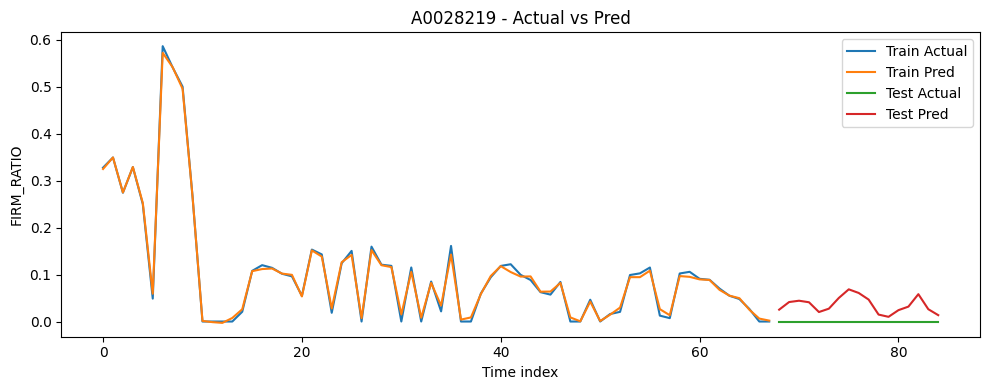


[A0028219] SHAP summary plot


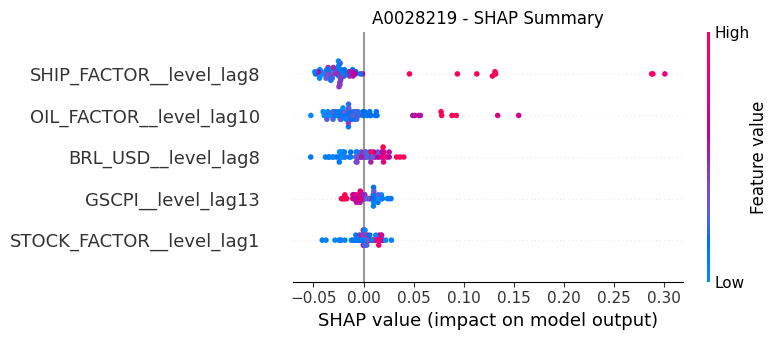


[A0028219] SHAP bar plot


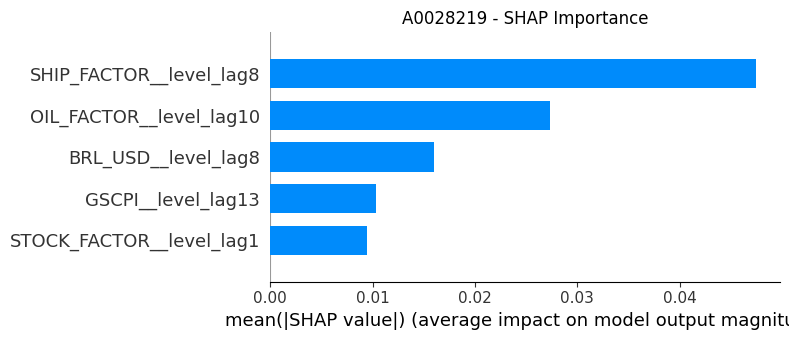


[A0030814X] XGBoost + SHAP
샘플 수: 68
피처 수: 8
피처 목록: ['OIL_FACTOR__level_lag1', 'SHIP_FACTOR__pct_lag1', 'STOCK_FACTOR__diff_lag8', 'BRL_USD__pct_lag11', 'IronOre_Price__level_lag2', 'GSCPI__level_lag12', 'US_AutoSales__pct_lag5', 'SOX__diff_lag7']
Train: (54, 8), Test: (14, 8)

[성능]
train_MAE   : 0.0022
train_RMSE  : 0.0029
train_R2    : 0.9993
test_MAE    : 0.0574
test_RMSE   : 0.0695
test_R2     : -0.6912
test_MAPE   : 110.6673

[XGBoost Importance Top 10]
                  feature  xgb_importance
       GSCPI__level_lag12        0.383388
  STOCK_FACTOR__diff_lag8        0.136979
IronOre_Price__level_lag2        0.131071
       BRL_USD__pct_lag11        0.113349
           SOX__diff_lag7        0.075130
   US_AutoSales__pct_lag5        0.069496
    SHIP_FACTOR__pct_lag1        0.054562
   OIL_FACTOR__level_lag1        0.036024

[SHAP Importance Top 10]
                  feature  mean_abs_shap
       GSCPI__level_lag12       0.032291
  STOCK_FACTOR__diff_lag8       0.031640
       BRL

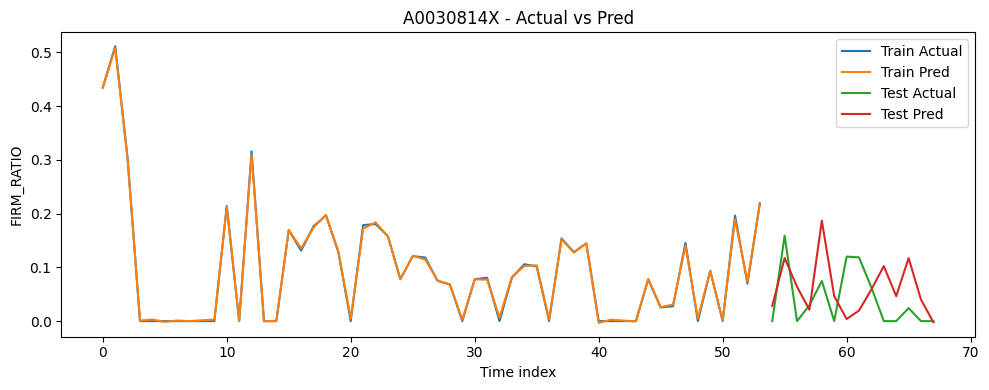


[A0030814X] SHAP summary plot


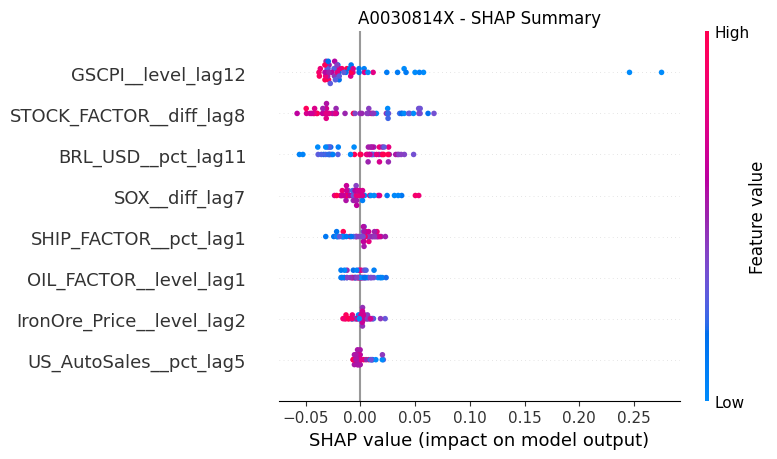


[A0030814X] SHAP bar plot


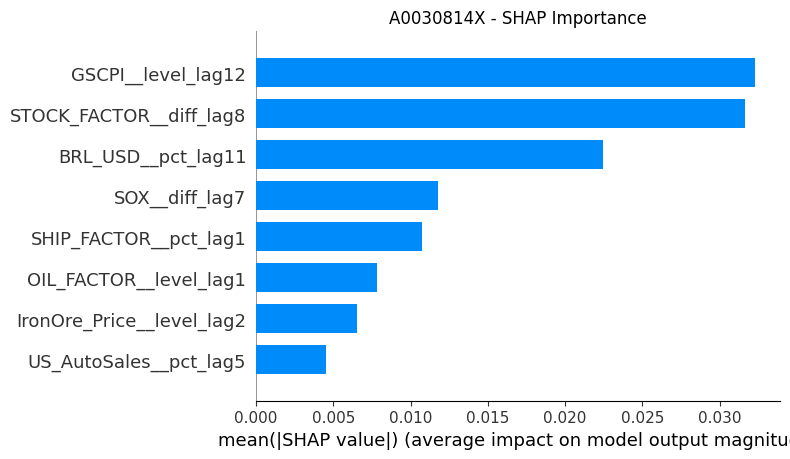


[A0049000] XGBoost + SHAP
샘플 수: 84
피처 수: 5
피처 목록: ['OIL_FACTOR__level_lag11', 'SHIP_FACTOR__level_lag6', 'STOCK_FACTOR__level_lag2', 'GSCPI__level_lag14', 'Brazil_CPI__level_lag3']
Train: (67, 5), Test: (17, 5)

[성능]
train_MAE   : 0.0041
train_RMSE  : 0.0054
train_R2    : 0.9979
test_MAE    : 0.0317
test_RMSE   : 0.0418
test_R2     : 0.0000
test_MAPE   : nan

[XGBoost Importance Top 10]
                 feature  xgb_importance
 OIL_FACTOR__level_lag11        0.307727
 SHIP_FACTOR__level_lag6        0.276583
  Brazil_CPI__level_lag3        0.239023
      GSCPI__level_lag14        0.128852
STOCK_FACTOR__level_lag2        0.047815

[SHAP Importance Top 10]
                 feature  mean_abs_shap
 OIL_FACTOR__level_lag11       0.034566
 SHIP_FACTOR__level_lag6       0.030572
      GSCPI__level_lag14       0.021264
STOCK_FACTOR__level_lag2       0.008208
  Brazil_CPI__level_lag3       0.003717


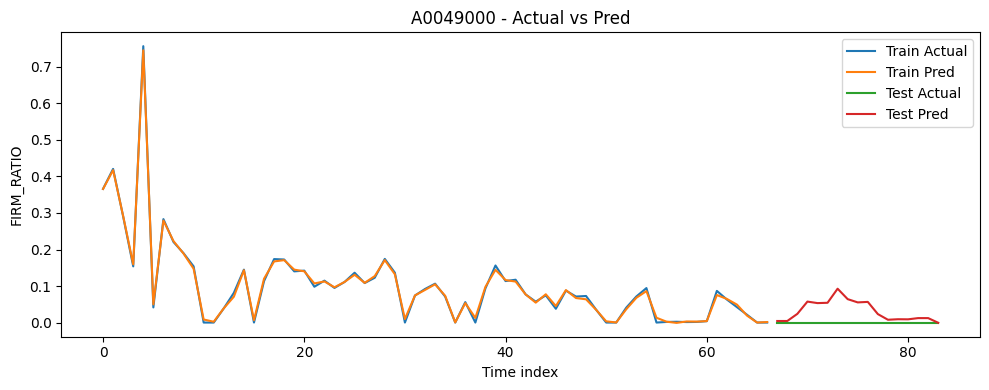


[A0049000] SHAP summary plot


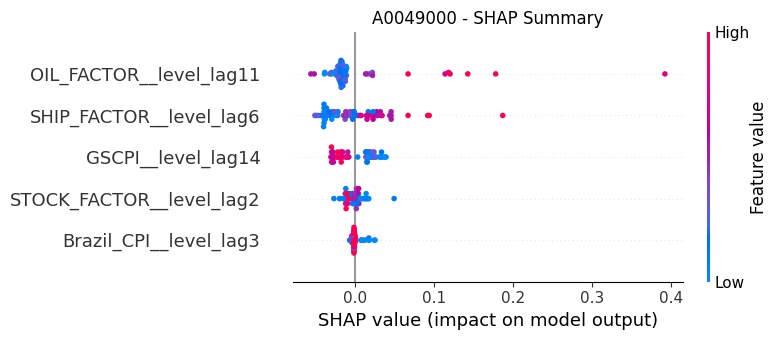


[A0049000] SHAP bar plot


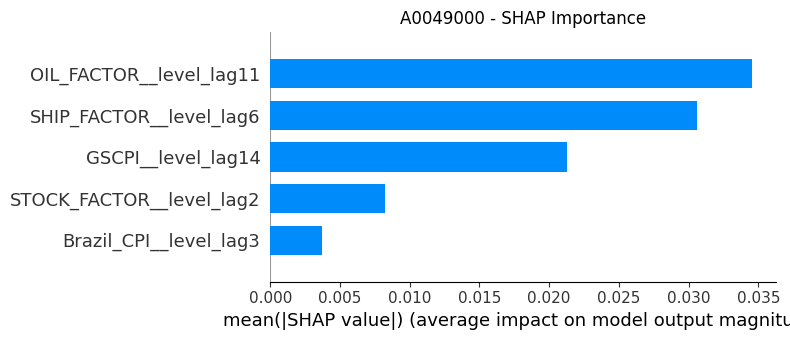


[A0067885] XGBoost + SHAP
샘플 수: 82
피처 수: 6
피처 목록: ['OIL_FACTOR__level_lag3', 'SHIP_FACTOR__level_lag1', 'STOCK_FACTOR__level_lag6', 'BRL_USD__pct_lag7', 'GSCPI__level_lag1', 'BR_AutoSales__level_lag16']
Train: (65, 6), Test: (17, 6)

[성능]
train_MAE   : 0.0062
train_RMSE  : 0.0076
train_R2    : 0.9969
test_MAE    : 0.0534
test_RMSE   : 0.0710
test_R2     : 0.0000
test_MAPE   : nan

[XGBoost Importance Top 10]
                  feature  xgb_importance
        GSCPI__level_lag1        0.399659
        BRL_USD__pct_lag7        0.212344
BR_AutoSales__level_lag16        0.119977
   OIL_FACTOR__level_lag3        0.105009
 STOCK_FACTOR__level_lag6        0.084779
  SHIP_FACTOR__level_lag1        0.078232

[SHAP Importance Top 10]
                  feature  mean_abs_shap
        GSCPI__level_lag1       0.039304
        BRL_USD__pct_lag7       0.031235
  SHIP_FACTOR__level_lag1       0.017491
 STOCK_FACTOR__level_lag6       0.013861
   OIL_FACTOR__level_lag3       0.012345
BR_AutoSales__level_l

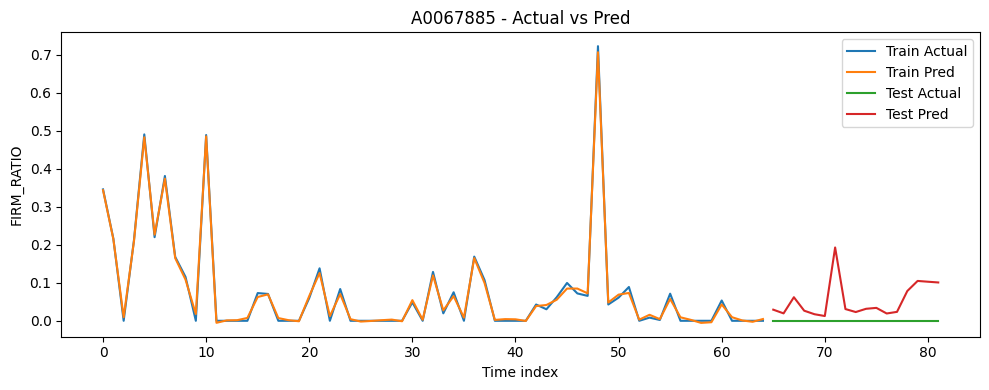


[A0067885] SHAP summary plot


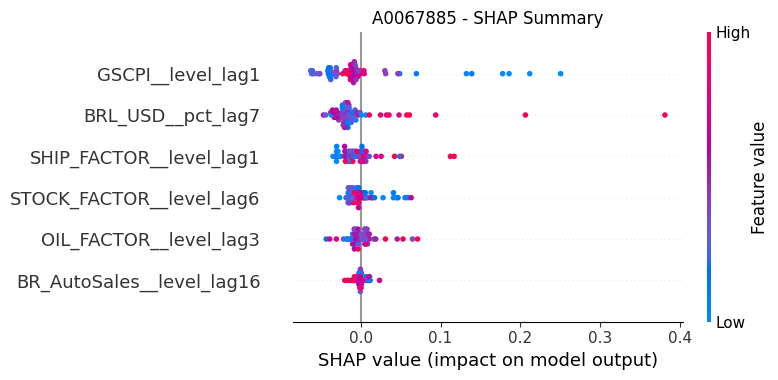


[A0067885] SHAP bar plot


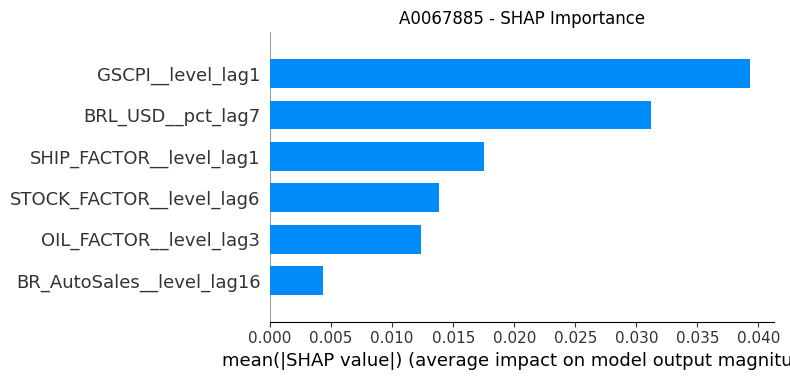


[A0070270] XGBoost + SHAP
샘플 수: 86
피처 수: 6
피처 목록: ['OIL_FACTOR__level_lag9', 'SHIP_FACTOR__level_lag3', 'STOCK_FACTOR__level_lag5', 'BRL_USD__pct_lag11', 'GSCPI__level_lag1', 'US_AutoSales__level_lag3']
Train: (68, 6), Test: (18, 6)

[성능]
train_MAE   : 0.0031
train_RMSE  : 0.0043
train_R2    : 0.9996
test_MAE    : 0.0364
test_RMSE   : 0.0440
test_R2     : 0.0000
test_MAPE   : nan

[XGBoost Importance Top 10]
                 feature  xgb_importance
  OIL_FACTOR__level_lag9        0.665258
       GSCPI__level_lag1        0.157559
 SHIP_FACTOR__level_lag3        0.124087
      BRL_USD__pct_lag11        0.028606
STOCK_FACTOR__level_lag5        0.019893
US_AutoSales__level_lag3        0.004598

[SHAP Importance Top 10]
                 feature  mean_abs_shap
  OIL_FACTOR__level_lag9       0.072584
       GSCPI__level_lag1       0.025156
 SHIP_FACTOR__level_lag3       0.018408
      BRL_USD__pct_lag11       0.012164
STOCK_FACTOR__level_lag5       0.008280
US_AutoSales__level_lag3       0.0

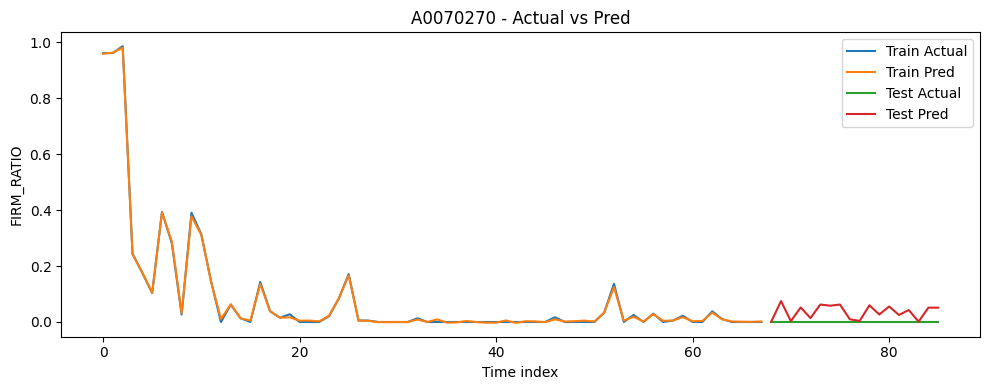


[A0070270] SHAP summary plot


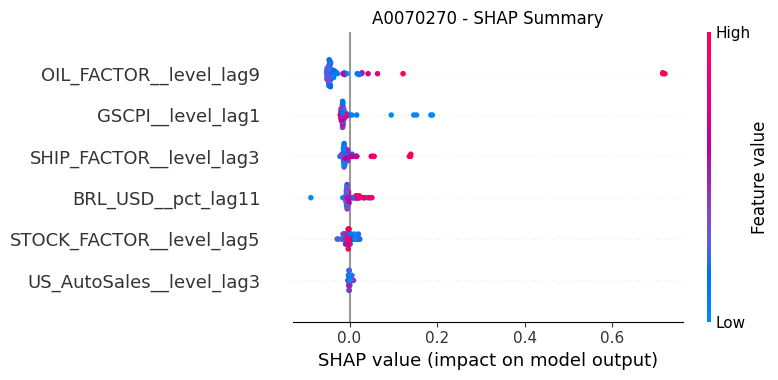


[A0070270] SHAP bar plot


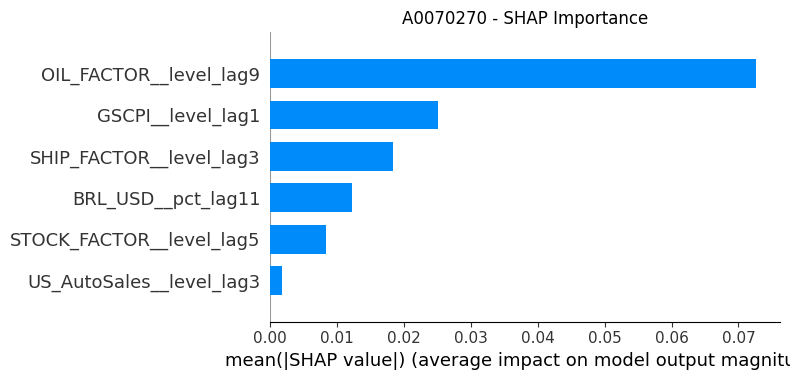


[A021N565] XGBoost + SHAP
샘플 수: 81
피처 수: 7
피처 목록: ['OIL_FACTOR__level_lag3', 'SHIP_FACTOR__level_lag1', 'STOCK_FACTOR__level_lag6', 'BRL_USD__diff_lag8', 'GSCPI__level_lag8', 'US_PMI__diff_lag16', 'SOX__level_lag16']
Train: (64, 7), Test: (17, 7)

[성능]
train_MAE   : 0.0058
train_RMSE  : 0.0073
train_R2    : 0.9982
test_MAE    : 0.0424
test_RMSE   : 0.0482
test_R2     : 0.0000
test_MAPE   : nan

[XGBoost Importance Top 10]
                 feature  xgb_importance
        SOX__level_lag16        0.239988
       GSCPI__level_lag8        0.180705
      US_PMI__diff_lag16        0.173965
 SHIP_FACTOR__level_lag1        0.132537
      BRL_USD__diff_lag8        0.109093
  OIL_FACTOR__level_lag3        0.106106
STOCK_FACTOR__level_lag6        0.057607

[SHAP Importance Top 10]
                 feature  mean_abs_shap
       GSCPI__level_lag8       0.038336
        SOX__level_lag16       0.033913
      BRL_USD__diff_lag8       0.018612
 SHIP_FACTOR__level_lag1       0.017122
STOCK_FACTOR__level

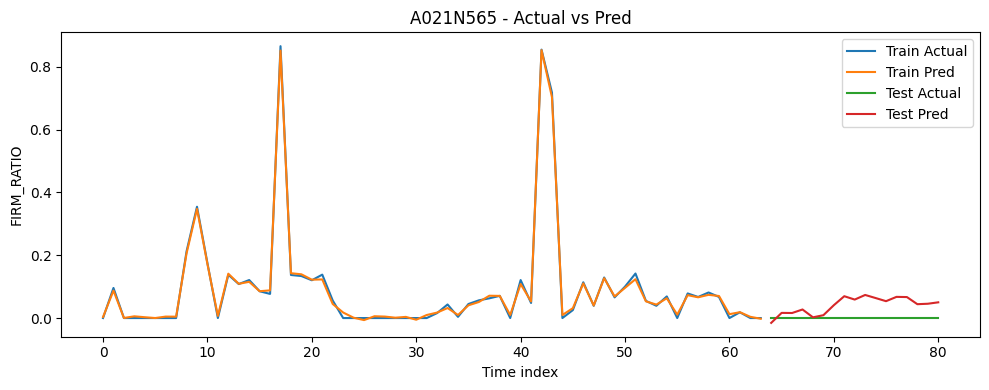


[A021N565] SHAP summary plot


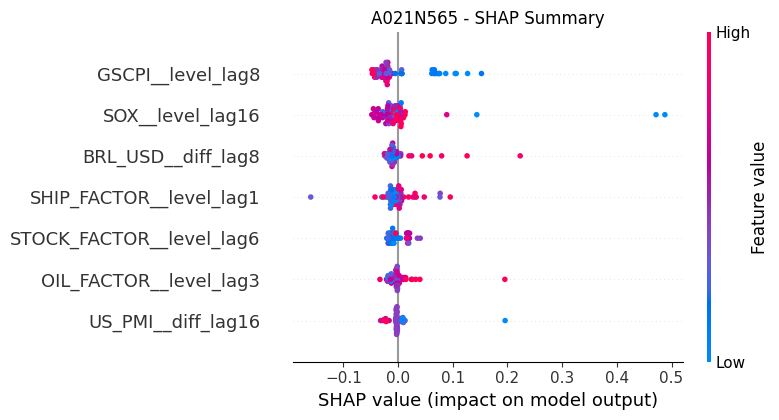


[A021N565] SHAP bar plot


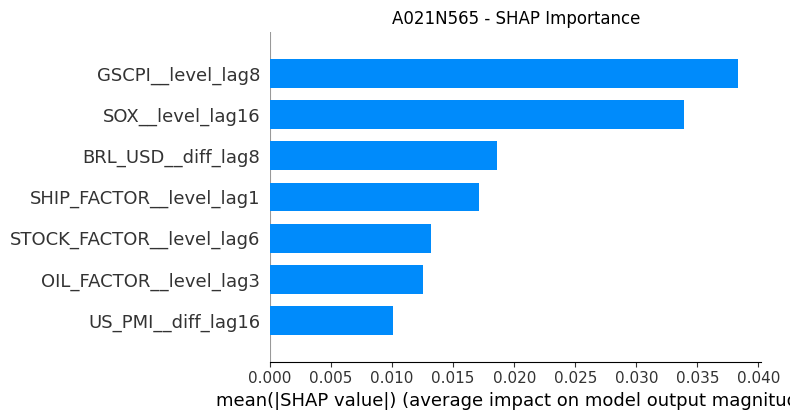


전체 성능 요약
 train_MAE  train_RMSE  train_R2  test_MAE  test_RMSE   test_R2  test_MAPE        PN
  0.004868    0.006579  0.997237  0.035558   0.039422  0.000000        NaN  A0028219
  0.002158    0.002883  0.999328  0.057384   0.069500 -0.691165 110.667288 A0030814X
  0.004078    0.005394  0.997902  0.031738   0.041778  0.000000        NaN  A0049000
  0.006210    0.007579  0.996913  0.053446   0.071036  0.000000        NaN  A0067885
  0.003122    0.004298  0.999581  0.036387   0.044008  0.000000        NaN  A0070270
  0.005766    0.007252  0.998245  0.042434   0.048214  0.000000        NaN  A021N565

✅ 저장 완료: /content/태림_XGBOOST_SHAP_결과.xlsx


In [11]:
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 0. 설정
# ---------------------------------------------------------
TEST_SIZE = 0.2
RANDOM_STATE = 42
OUTPUT_SHAP_PATH = "/content/태림_XGBOOST_SHAP_결과.xlsx"

# ---------------------------------------------------------
# 1. 보조 함수
# ---------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def time_series_split(X, y, test_size=0.2):
    n = len(X)
    split_idx = int(n * (1 - test_size))
    X_train = X.iloc[:split_idx].copy()
    X_test  = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test  = y.iloc[split_idx:].copy()
    return X_train, X_test, y_train, y_test

def train_xgb_regressor(X_train, y_train):
    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    metrics = {
        "train_MAE":  mean_absolute_error(y_train, pred_train),
        "train_RMSE": rmse(y_train, pred_train),
        "train_R2":   r2_score(y_train, pred_train),

        "test_MAE":   mean_absolute_error(y_test, pred_test),
        "test_RMSE":  rmse(y_test, pred_test),
        "test_R2":    r2_score(y_test, pred_test),
        "test_MAPE":  mape(y_test, pred_test),
    }
    return metrics, pred_train, pred_test

def get_xgb_importance(model, feature_names):
    imp = model.feature_importances_
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "xgb_importance": imp
    }).sort_values("xgb_importance", ascending=False).reset_index(drop=True)
    return df_imp

def get_shap_importance(model, X_train):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)

    shap_imp = np.abs(shap_values).mean(axis=0)
    df_shap = pd.DataFrame({
        "feature": X_train.columns,
        "mean_abs_shap": shap_imp
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return explainer, shap_values, df_shap

def plot_actual_vs_pred(y_train, pred_train, y_test, pred_test, pn):
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(y_train)), y_train.values, label="Train Actual")
    plt.plot(range(len(y_train)), pred_train, label="Train Pred")
    plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test.values, label="Test Actual")
    plt.plot(range(len(y_train), len(y_train)+len(y_test)), pred_test, label="Test Pred")
    plt.title(f"{pn} - Actual vs Pred")
    plt.xlabel("Time index")
    plt.ylabel("FIRM_RATIO")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_shap_summary(shap_values, X_train, pn):
    print(f"\n[{pn}] SHAP summary plot")
    shap.summary_plot(shap_values, X_train, show=False)
    plt.title(f"{pn} - SHAP Summary")
    plt.tight_layout()
    plt.show()

def plot_shap_bar(shap_values, X_train, pn):
    print(f"\n[{pn}] SHAP bar plot")
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
    plt.title(f"{pn} - SHAP Importance")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. 품명별 실행
# ---------------------------------------------------------
metrics_all = []
xgb_importance_by_pn = {}
shap_importance_by_pn = {}
predictions_by_pn = {}

trained_models = {}

for pn, (X, y) in model_data.items():
    print("\n" + "="*80)
    print(f"[{pn}] XGBoost + SHAP")
    print("="*80)

    # 혹시나 결측 정리
    data = pd.concat([X, y.rename("target")], axis=1).dropna().reset_index(drop=True)
    X_clean = data.drop(columns=["target"])
    y_clean = data["target"]

    print(f"샘플 수: {len(X_clean)}")
    print(f"피처 수: {X_clean.shape[1]}")
    print("피처 목록:", list(X_clean.columns))

    # 시계열 분할
    X_train, X_test, y_train, y_test = time_series_split(X_clean, y_clean, test_size=TEST_SIZE)
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")

    # 모델 학습
    model = train_xgb_regressor(X_train, y_train)
    trained_models[pn] = model

    # 성능 평가
    metrics, pred_train, pred_test = evaluate_model(model, X_train, y_train, X_test, y_test)
    metrics["PN"] = pn
    metrics_all.append(metrics)

    print("\n[성능]")
    for k, v in metrics.items():
        if k != "PN":
            print(f"{k:12s}: {v:.4f}")

    # 예측 결과 저장
    pred_df = pd.DataFrame({
        "set": ["train"] * len(y_train) + ["test"] * len(y_test),
        "actual": np.concatenate([y_train.values, y_test.values]),
        "pred":   np.concatenate([pred_train, pred_test])
    })
    predictions_by_pn[pn] = pred_df

    # XGBoost 기본 importance
    df_xgb_imp = get_xgb_importance(model, X_train.columns)
    xgb_importance_by_pn[pn] = df_xgb_imp

    print("\n[XGBoost Importance Top 10]")
    print(df_xgb_imp.head(10).to_string(index=False))

    # SHAP importance
    explainer, shap_values, df_shap_imp = get_shap_importance(model, X_train)
    shap_importance_by_pn[pn] = df_shap_imp

    print("\n[SHAP Importance Top 10]")
    print(df_shap_imp.head(10).to_string(index=False))

    # 시각화
    plot_actual_vs_pred(y_train, pred_train, y_test, pred_test, pn)
    plot_shap_summary(shap_values, X_train, pn)
    plot_shap_bar(shap_values, X_train, pn)

# ---------------------------------------------------------
# 3. 전체 성능 요약
# ---------------------------------------------------------
metrics_df = pd.DataFrame(metrics_all)
print("\n" + "="*80)
print("전체 성능 요약")
print("="*80)
print(metrics_df.to_string(index=False))

# ---------------------------------------------------------
# 4. 엑셀 저장
# ---------------------------------------------------------
with pd.ExcelWriter(OUTPUT_SHAP_PATH, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)

    for pn in trained_models.keys():
        if pn in xgb_importance_by_pn:
            xgb_importance_by_pn[pn].to_excel(writer, sheet_name=f"{pn}_xgb_imp"[:31], index=False)

        if pn in shap_importance_by_pn:
            shap_importance_by_pn[pn].to_excel(writer, sheet_name=f"{pn}_shap_imp"[:31], index=False)

        if pn in predictions_by_pn:
            predictions_by_pn[pn].to_excel(writer, sheet_name=f"{pn}_pred"[:31], index=False)

print(f"\n✅ 저장 완료: {OUTPUT_SHAP_PATH}")

- A0030814X: 현재 외부변수 8개인데 과하다
US_AutoSales__pct_lag5
IronOre_Price__level_lag2
OIL_FACTOR__level_lag1
SHAP 기준 하위에 있는 것들을 제거해야함.
- A0067885
BR_AutoSales__lag16
SHAP 거의 없고 lag 너무 길어서 제거해야함.
- A0070270
US_AutoSales__lag3
SHAP 영향 거의 없어서 제거.

In [13]:
# 1. Firm이 존재하는 마지막 위치 찾기
valid_idx = y_clean[y_clean > 0].index

if len(valid_idx) == 0:
    print("이 품명은 Firm 없음 → 모델링 불가")
else:
    last_firm_idx = valid_idx.max()

# 2. 그 이전까지만 사용
X_valid = X_clean.loc[:last_firm_idx]
y_valid = y_clean.loc[:last_firm_idx]

# 3. 여기서 8:2 split
X_train, X_test, y_train, y_test = time_series_split(X_valid, y_valid, test_size=0.2)


[A0028219] XGBoost + SHAP / valid FIRM_RATIO split
[A0028219] 제거 변수 없음
전체 샘플 수: 85
전체 non-zero 개수: 54
전체 0 비율: 0.365
피처 수: 5
평가 사용 샘플 수: 66
제외된 최신 샘플 수: 19
last_valid_idx: 65
Train: (52, 5), Test: (14, 5)
Train non-zero 개수: 40
Test non-zero 개수: 14
Test 0 비율: 0.000

[성능]
train_MAE               : 0.0510
train_RMSE              : 0.0727
train_R2                : 0.7227
test_MAE                : 0.0346
test_RMSE               : 0.0377
test_R2                 : -0.0382
test_MAPE               : 124.2521
n_features              : 5
eval_samples            : 66
excluded_recent_samples : 19
test_nonzero            : 14
test_zero_ratio         : 0.0000

[XGBoost Importance Top 10]
                 feature  xgb_importance
 OIL_FACTOR__level_lag10        0.454912
 SHIP_FACTOR__level_lag8        0.352319
     BRL_USD__level_lag8        0.076293
      GSCPI__level_lag13        0.062970
STOCK_FACTOR__level_lag1        0.053507

[SHAP Importance Top 10]
                 feature  mean_abs_shap
 SHIP

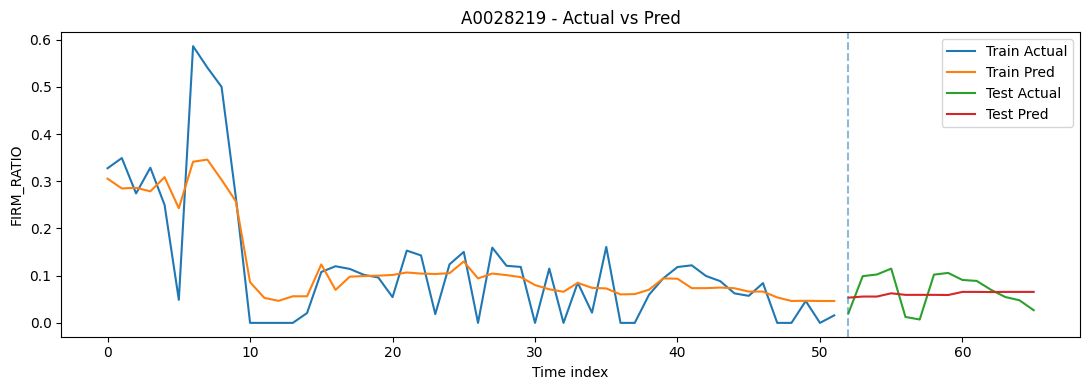


[A0028219] SHAP summary plot


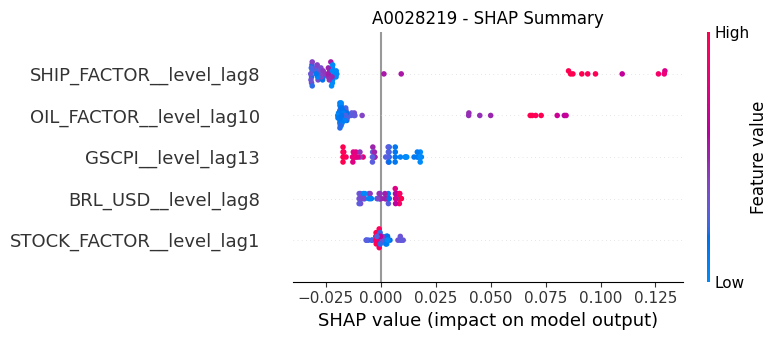


[A0028219] SHAP bar plot


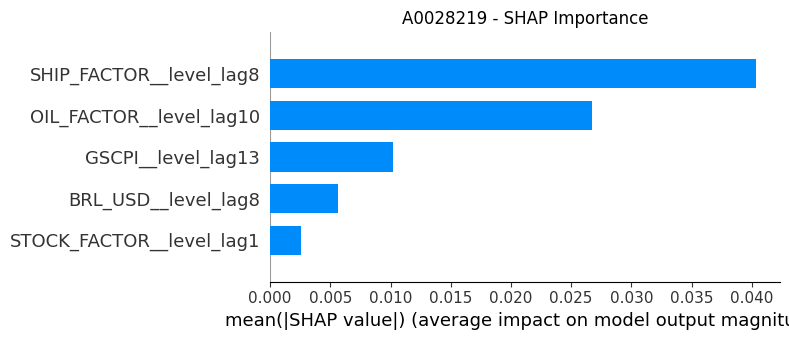


[A0030814X] XGBoost + SHAP / valid FIRM_RATIO split
[A0030814X] 제거 변수: ['US_AutoSales__pct_lag5', 'IronOre_Price__level_lag2', 'OIL_FACTOR__level_lag1']
전체 샘플 수: 68
전체 non-zero 개수: 41
전체 0 비율: 0.397
피처 수: 5
평가 사용 샘플 수: 66
제외된 최신 샘플 수: 2
last_valid_idx: 65
Train: (52, 5), Test: (14, 5)
Train non-zero 개수: 32
Test non-zero 개수: 9
Test 0 비율: 0.357

[성능]
train_MAE               : 0.0571
train_RMSE              : 0.0741
train_R2                : 0.5622
test_MAE                : 0.0529
test_RMSE               : 0.0582
test_R2                 : 0.2431
test_MAPE               : 71.3273
n_features              : 5
eval_samples            : 66
excluded_recent_samples : 2
test_nonzero            : 9
test_zero_ratio         : 0.3571

[XGBoost Importance Top 10]
                feature  xgb_importance
     GSCPI__level_lag12        0.378749
         SOX__diff_lag7        0.199748
     BRL_USD__pct_lag11        0.175895
STOCK_FACTOR__diff_lag8        0.162180
  SHIP_FACTOR__pct_lag1        0.083427



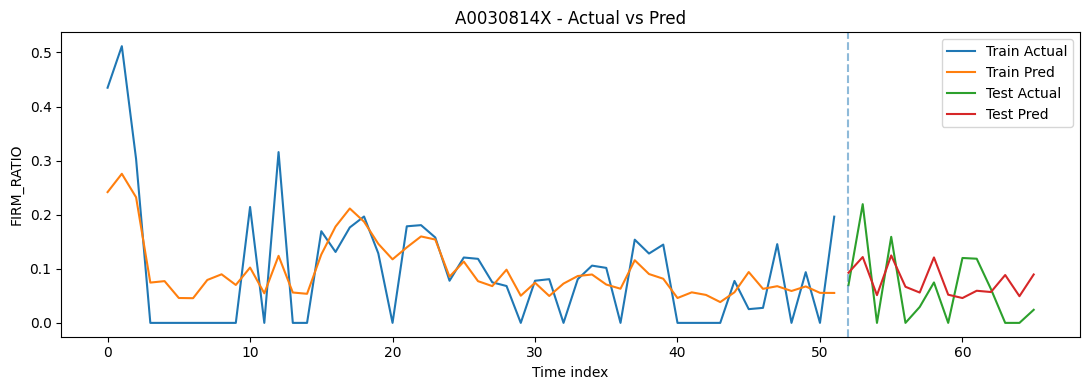


[A0030814X] SHAP summary plot


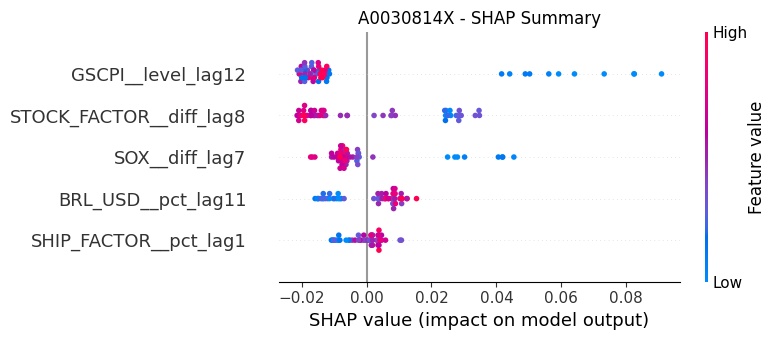


[A0030814X] SHAP bar plot


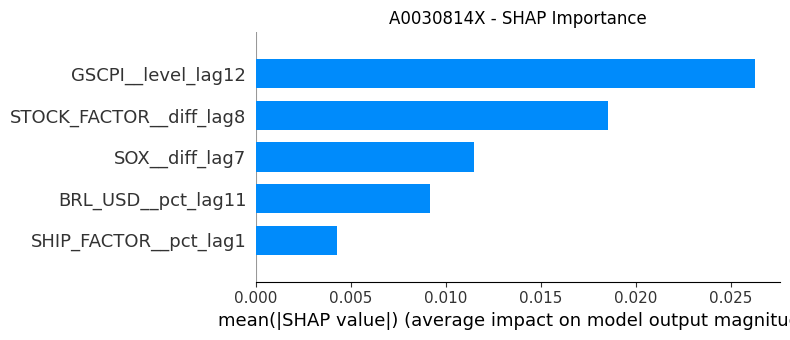


[A0049000] XGBoost + SHAP / valid FIRM_RATIO split
[A0049000] 제거 변수 없음
전체 샘플 수: 84
전체 non-zero 개수: 56
전체 0 비율: 0.333
피처 수: 5
평가 사용 샘플 수: 65
제외된 최신 샘플 수: 19
last_valid_idx: 64
Train: (52, 5), Test: (13, 5)
Train non-zero 개수: 44
Test non-zero 개수: 12
Test 0 비율: 0.077

[성능]
train_MAE               : 0.0443
train_RMSE              : 0.0788
train_R2                : 0.6012
test_MAE                : 0.0454
test_RMSE               : 0.0523
test_R2                 : -1.3440
test_MAPE               : 1574.0151
n_features              : 5
eval_samples            : 65
excluded_recent_samples : 19
test_nonzero            : 12
test_zero_ratio         : 0.0769

[XGBoost Importance Top 10]
                 feature  xgb_importance
 OIL_FACTOR__level_lag11        0.351000
  Brazil_CPI__level_lag3        0.340296
 SHIP_FACTOR__level_lag6        0.240056
      GSCPI__level_lag14        0.039730
STOCK_FACTOR__level_lag2        0.028918

[SHAP Importance Top 10]
                 feature  mean_abs_shap
 SHI

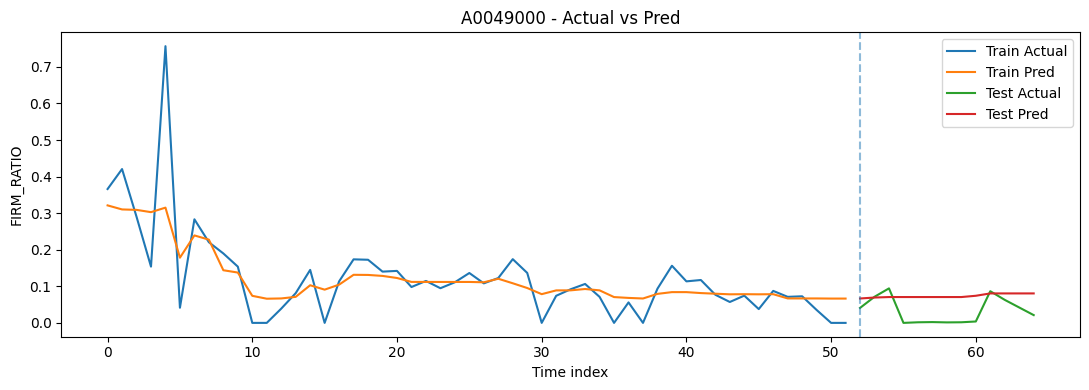


[A0049000] SHAP summary plot


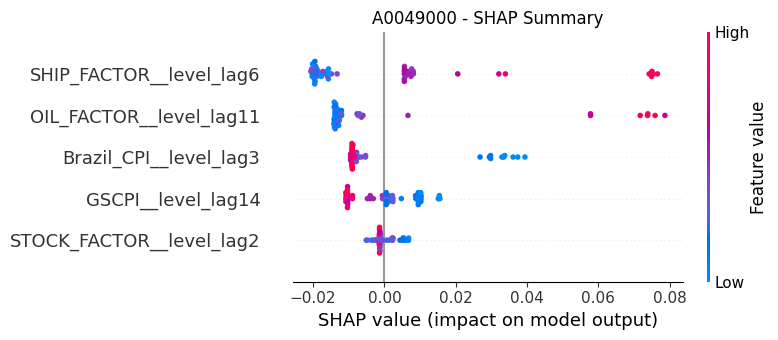


[A0049000] SHAP bar plot


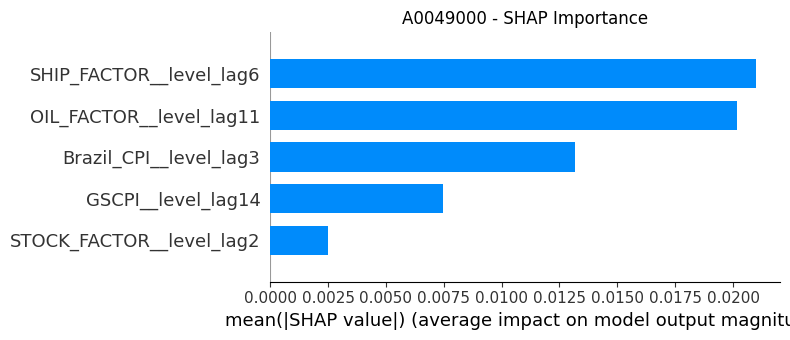


[A0067885] XGBoost + SHAP / valid FIRM_RATIO split
[A0067885] 제거 변수: ['BR_AutoSales__level_lag16']
전체 샘플 수: 82
전체 non-zero 개수: 34
전체 0 비율: 0.585
피처 수: 5
평가 사용 샘플 수: 61
제외된 최신 샘플 수: 21
last_valid_idx: 60
Train: (48, 5), Test: (13, 5)
Train non-zero 개수: 26
Test non-zero 개수: 8
Test 0 비율: 0.385

[성능]
train_MAE               : 0.0585
train_RMSE              : 0.0838
train_R2                : 0.5349
test_MAE                : 0.0812
test_RMSE               : 0.1862
test_R2                 : 0.0163
test_MAPE               : 322.9991
n_features              : 5
eval_samples            : 61
excluded_recent_samples : 21
test_nonzero            : 8
test_zero_ratio         : 0.3846

[XGBoost Importance Top 10]
                 feature  xgb_importance
       GSCPI__level_lag1        0.400192
 SHIP_FACTOR__level_lag1        0.273073
       BRL_USD__pct_lag7        0.145320
  OIL_FACTOR__level_lag3        0.108220
STOCK_FACTOR__level_lag6        0.073195

[SHAP Importance Top 10]
                 fea

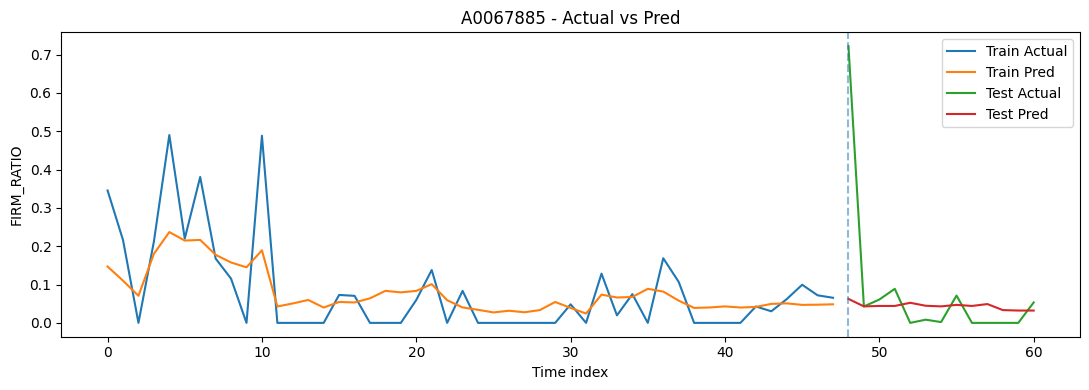


[A0067885] SHAP summary plot


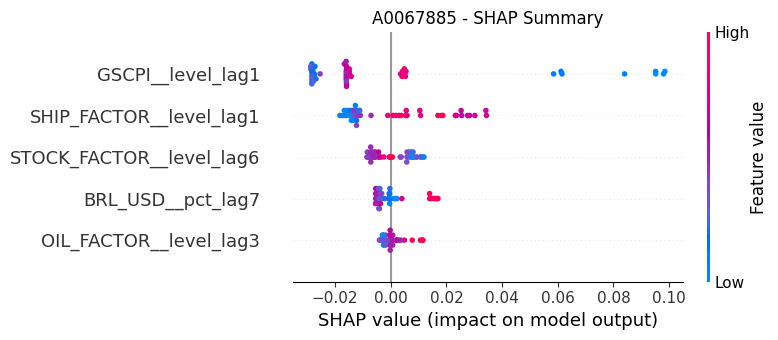


[A0067885] SHAP bar plot


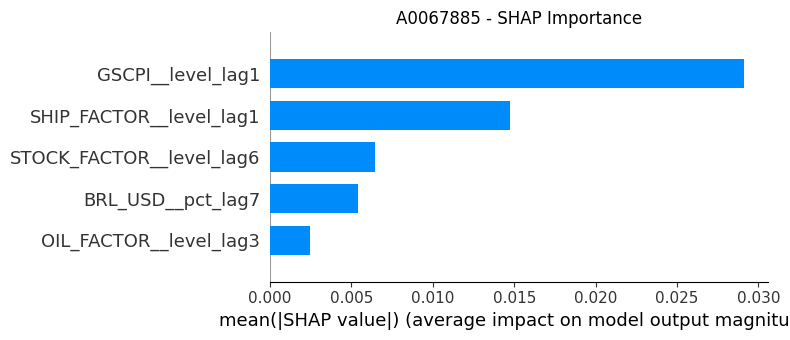


[A0070270] XGBoost + SHAP / valid FIRM_RATIO split
[A0070270] 제거 변수: ['US_AutoSales__level_lag3']
전체 샘플 수: 86
전체 non-zero 개수: 33
전체 0 비율: 0.616
피처 수: 5
평가 사용 샘플 수: 64
제외된 최신 샘플 수: 22
last_valid_idx: 63
Train: (51, 5), Test: (13, 5)
Train non-zero 개수: 25
Test non-zero 개수: 8
Test 0 비율: 0.385

[성능]
train_MAE               : 0.0497
train_RMSE              : 0.0789
train_R2                : 0.8896
test_MAE                : 0.0203
test_RMSE               : 0.0370
test_R2                 : -0.0848
test_MAPE               : 57.6138
n_features              : 5
eval_samples            : 64
excluded_recent_samples : 22
test_nonzero            : 8
test_zero_ratio         : 0.3846

[XGBoost Importance Top 10]
                 feature  xgb_importance
 SHIP_FACTOR__level_lag3        0.378024
  OIL_FACTOR__level_lag9        0.330689
STOCK_FACTOR__level_lag5        0.174970
      BRL_USD__pct_lag11        0.063930
       GSCPI__level_lag1        0.052387

[SHAP Importance Top 10]
                 feat

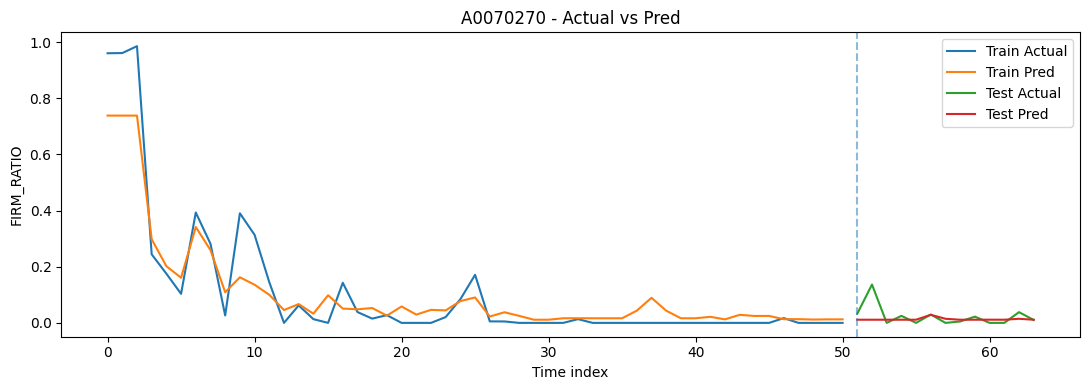


[A0070270] SHAP summary plot


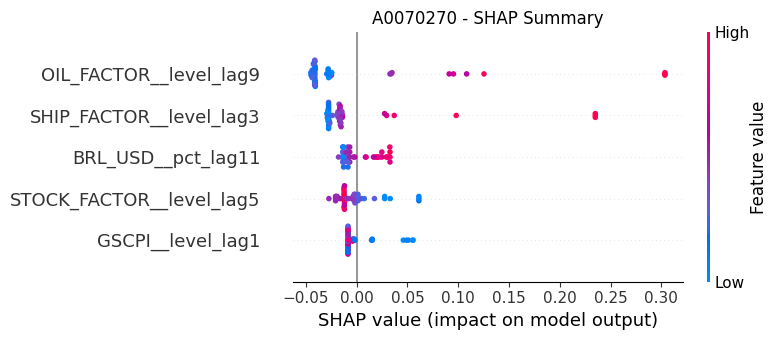


[A0070270] SHAP bar plot


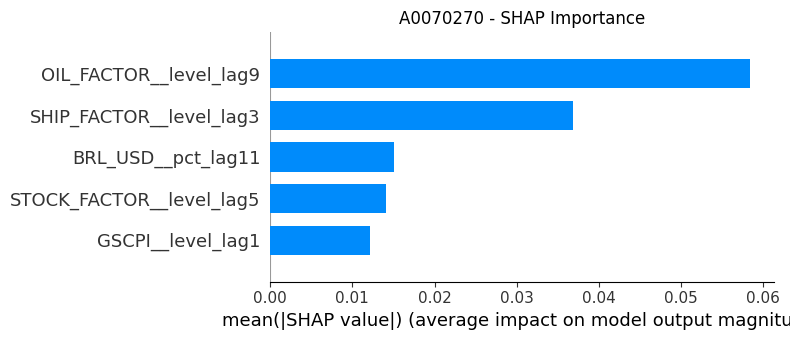


[A021N565] XGBoost + SHAP / valid FIRM_RATIO split
[A021N565] 제거 변수 없음
전체 샘플 수: 81
전체 non-zero 개수: 41
전체 0 비율: 0.494
피처 수: 7
평가 사용 샘플 수: 62
제외된 최신 샘플 수: 19
last_valid_idx: 61
Train: (49, 7), Test: (13, 7)
Train non-zero 개수: 30
Test non-zero 개수: 11
Test 0 비율: 0.154

[성능]
train_MAE               : 0.0734
train_RMSE              : 0.1424
train_R2                : 0.4661
test_MAE                : 0.0418
test_RMSE               : 0.0520
test_R2                 : -0.8724
test_MAPE               : 76.8869
n_features              : 7
eval_samples            : 62
excluded_recent_samples : 19
test_nonzero            : 11
test_zero_ratio         : 0.1538

[XGBoost Importance Top 10]
                 feature  xgb_importance
        SOX__level_lag16        0.244149
STOCK_FACTOR__level_lag6        0.202467
 SHIP_FACTOR__level_lag1        0.130900
      BRL_USD__diff_lag8        0.125464
  OIL_FACTOR__level_lag3        0.116212
       GSCPI__level_lag8        0.111147
      US_PMI__diff_lag16       

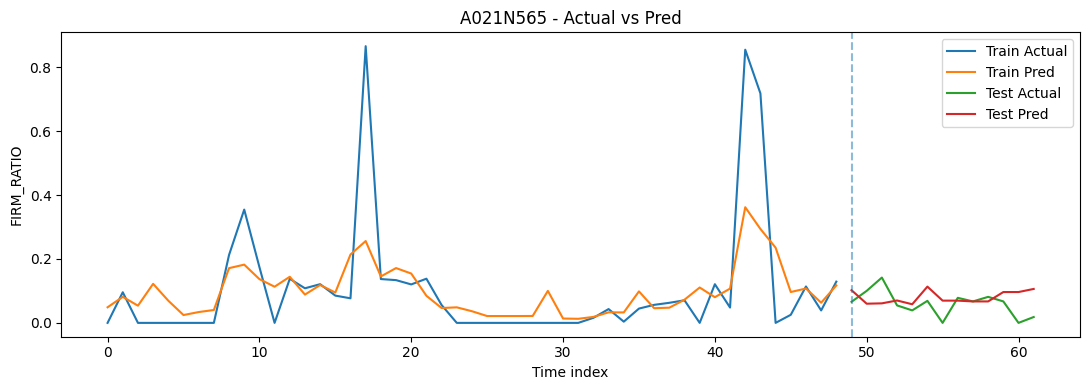


[A021N565] SHAP summary plot


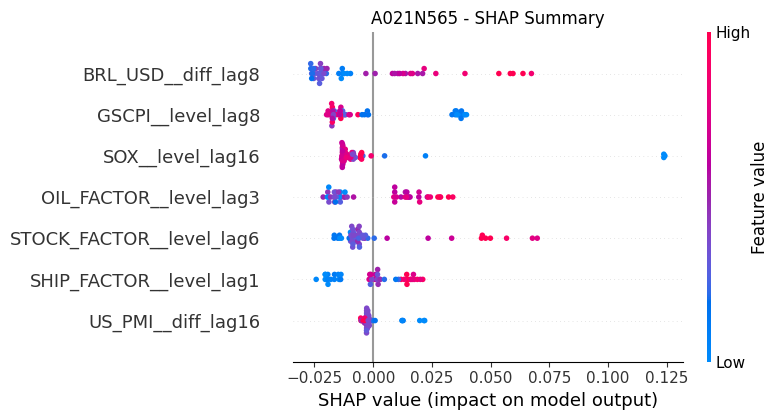


[A021N565] SHAP bar plot


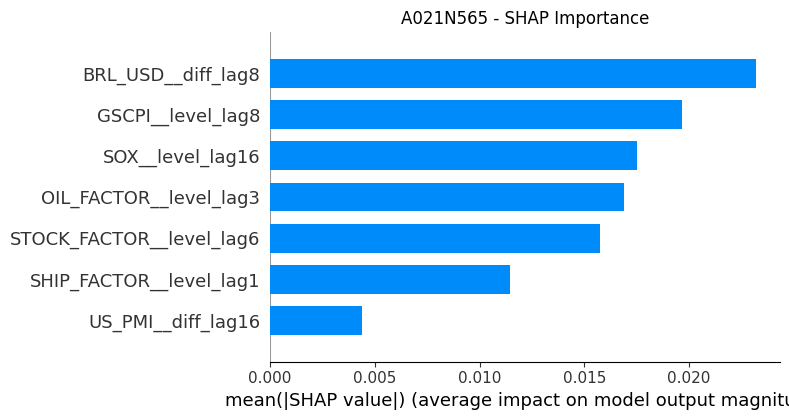


전체 성능 요약
 train_MAE  train_RMSE  train_R2  test_MAE  test_RMSE   test_R2   test_MAPE        PN  n_features  eval_samples  excluded_recent_samples  test_nonzero  test_zero_ratio
  0.050973    0.072697  0.722663  0.034600   0.037743 -0.038178  124.252095  A0028219           5            66                       19            14         0.000000
  0.057073    0.074095  0.562151  0.052870   0.058239  0.243124   71.327284 A0030814X           5            66                        2             9         0.357143
  0.044261    0.078806  0.601154  0.045374   0.052280 -1.344004 1574.015092  A0049000           5            65                       19            12         0.076923
  0.058535    0.083843  0.534927  0.081188   0.186209  0.016280  322.999109  A0067885           5            61                       21             8         0.384615
  0.049690    0.078865  0.889640  0.020259   0.036994 -0.084834   57.613817  A0070270           5            64                       22             8

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 0. 설정
# =========================================================
TEST_SIZE = 0.2
RANDOM_STATE = 42
OUTPUT_PATH = "/content/태림_XGBOOST_SHAP_결과_v3_valid_split.xlsx"

DROP_FEATURES_BY_PN = {
    "A0030814X": [
        "US_AutoSales__pct_lag5",
        "IronOre_Price__level_lag2",
        "OIL_FACTOR__level_lag1",
    ],
    "A0067885": [
        "BR_AutoSales__level_lag16",
    ],
    "A0070270": [
        "US_AutoSales__level_lag3",
    ],
}

# =========================================================
# 1. 보조 함수
# =========================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def valid_time_series_split(X, y, test_size=0.2, min_test_nonzero=1):
    """
    FIRM_RATIO 회귀용 시계열 split.
    핵심:
    - 전체 최신 구간을 무조건 test로 쓰지 않음
    - y > 0이 마지막으로 관측된 지점까지만 평가용 데이터로 사용
    - 그 안에서 시간순 8:2 split
    """

    y = y.reset_index(drop=True)
    X = X.reset_index(drop=True)

    nonzero_idx = y[y > 0].index

    if len(nonzero_idx) == 0:
        raise ValueError("FIRM_RATIO가 0보다 큰 구간이 없습니다. 이 품명은 회귀 평가가 어렵습니다.")

    last_valid_idx = nonzero_idx.max()

    X_eval = X.iloc[:last_valid_idx + 1].copy()
    y_eval = y.iloc[:last_valid_idx + 1].copy()

    n = len(X_eval)
    split_idx = int(n * (1 - test_size))

    X_train = X_eval.iloc[:split_idx].copy()
    X_test  = X_eval.iloc[split_idx:].copy()
    y_train = y_eval.iloc[:split_idx].copy()
    y_test  = y_eval.iloc[split_idx:].copy()

    # 그래도 test에 non-zero가 너무 없으면 split 위치를 앞으로 당김
    if (y_test > 0).sum() < min_test_nonzero:
        candidate_splits = range(int(n * 0.5), split_idx)

        found = False
        for s in reversed(list(candidate_splits)):
            temp_y_test = y_eval.iloc[s:]
            if (temp_y_test > 0).sum() >= min_test_nonzero:
                split_idx = s
                found = True
                break

        if found:
            X_train = X_eval.iloc[:split_idx].copy()
            X_test  = X_eval.iloc[split_idx:].copy()
            y_train = y_eval.iloc[:split_idx].copy()
            y_test  = y_eval.iloc[split_idx:].copy()

    return X_train, X_test, y_train, y_test, X_eval, y_eval, last_valid_idx

def train_xgb_regressor(X_train, y_train):
    model = XGBRegressor(
        n_estimators=120,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=3,
        reg_alpha=0.3,
        reg_lambda=2.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        eval_metric="rmse"
    )
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    metrics = {
        "train_MAE":  mean_absolute_error(y_train, pred_train),
        "train_RMSE": rmse(y_train, pred_train),
        "train_R2":   r2_score(y_train, pred_train),

        "test_MAE":   mean_absolute_error(y_test, pred_test),
        "test_RMSE":  rmse(y_test, pred_test),
        "test_R2":    r2_score(y_test, pred_test),
        "test_MAPE":  mape(y_test, pred_test),
    }

    return metrics, pred_train, pred_test

def get_xgb_importance(model, feature_names):
    return pd.DataFrame({
        "feature": feature_names,
        "xgb_importance": model.feature_importances_
    }).sort_values("xgb_importance", ascending=False).reset_index(drop=True)

def get_shap_importance(model, X_train):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)

    df_shap = pd.DataFrame({
        "feature": X_train.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return explainer, shap_values, df_shap

def plot_actual_vs_pred(y_train, pred_train, y_test, pred_test, pn):
    plt.figure(figsize=(11, 4))

    plt.plot(range(len(y_train)), y_train.values, label="Train Actual")
    plt.plot(range(len(y_train)), pred_train, label="Train Pred")

    test_x = range(len(y_train), len(y_train) + len(y_test))
    plt.plot(test_x, y_test.values, label="Test Actual")
    plt.plot(test_x, pred_test, label="Test Pred")

    plt.axvline(len(y_train), linestyle="--", alpha=0.5)
    plt.title(f"{pn} - Actual vs Pred")
    plt.xlabel("Time index")
    plt.ylabel("FIRM_RATIO")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_shap_summary(shap_values, X_train, pn):
    print(f"\n[{pn}] SHAP summary plot")
    shap.summary_plot(shap_values, X_train, show=False)
    plt.title(f"{pn} - SHAP Summary")
    plt.tight_layout()
    plt.show()

def plot_shap_bar(shap_values, X_train, pn):
    print(f"\n[{pn}] SHAP bar plot")
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
    plt.title(f"{pn} - SHAP Importance")
    plt.tight_layout()
    plt.show()

# =========================================================
# 2. 품명별 실행
# =========================================================
metrics_all = []
xgb_importance_by_pn = {}
shap_importance_by_pn = {}
predictions_by_pn = {}
trained_models = {}
final_feature_list_by_pn = {}
split_info_by_pn = {}

for pn, (X, y) in model_data.items():
    print("\n" + "="*80)
    print(f"[{pn}] XGBoost + SHAP / valid FIRM_RATIO split")
    print("="*80)

    # -----------------------------------------------------
    # 2-1. 품명별 변수 제거
    # -----------------------------------------------------
    X_use = X.copy()

    drop_cols = DROP_FEATURES_BY_PN.get(pn, [])
    drop_cols = [c for c in drop_cols if c in X_use.columns]

    if drop_cols:
        print(f"[{pn}] 제거 변수: {drop_cols}")
        X_use = X_use.drop(columns=drop_cols)
    else:
        print(f"[{pn}] 제거 변수 없음")

    # -----------------------------------------------------
    # 2-2. 결측 제거
    # -----------------------------------------------------
    data = pd.concat([X_use, y.rename("target")], axis=1).dropna().reset_index(drop=True)

    X_clean = data.drop(columns=["target"])
    y_clean = data["target"]

    final_feature_list_by_pn[pn] = pd.DataFrame({"feature": X_clean.columns})

    print(f"전체 샘플 수: {len(X_clean)}")
    print(f"전체 non-zero 개수: {(y_clean > 0).sum()}")
    print(f"전체 0 비율: {(y_clean == 0).mean():.3f}")
    print(f"피처 수: {X_clean.shape[1]}")

    # -----------------------------------------------------
    # 2-3. FIRM_RATIO 실제 관측 구간 기준 split
    # -----------------------------------------------------
    try:
        X_train, X_test, y_train, y_test, X_eval, y_eval, last_valid_idx = valid_time_series_split(
            X_clean,
            y_clean,
            test_size=TEST_SIZE,
            min_test_nonzero=1
        )
    except ValueError as e:
        print(f"[{pn}] 스킵: {e}")
        continue

    print(f"평가 사용 샘플 수: {len(X_eval)}")
    print(f"제외된 최신 샘플 수: {len(X_clean) - len(X_eval)}")
    print(f"last_valid_idx: {last_valid_idx}")
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"Train non-zero 개수: {(y_train > 0).sum()}")
    print(f"Test non-zero 개수: {(y_test > 0).sum()}")
    print(f"Test 0 비율: {(y_test == 0).mean():.3f}")

    split_info_by_pn[pn] = pd.DataFrame([{
        "PN": pn,
        "total_samples": len(X_clean),
        "eval_samples": len(X_eval),
        "excluded_recent_samples": len(X_clean) - len(X_eval),
        "last_valid_idx": last_valid_idx,
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "train_nonzero": int((y_train > 0).sum()),
        "test_nonzero": int((y_test > 0).sum()),
        "test_zero_ratio": float((y_test == 0).mean())
    }])

    # -----------------------------------------------------
    # 2-4. 모델 학습
    # -----------------------------------------------------
    model = train_xgb_regressor(X_train, y_train)
    trained_models[pn] = model

    # -----------------------------------------------------
    # 2-5. 성능 평가
    # -----------------------------------------------------
    metrics, pred_train, pred_test = evaluate_model(
        model, X_train, y_train, X_test, y_test
    )

    metrics["PN"] = pn
    metrics["n_features"] = X_clean.shape[1]
    metrics["eval_samples"] = len(X_eval)
    metrics["excluded_recent_samples"] = len(X_clean) - len(X_eval)
    metrics["test_nonzero"] = int((y_test > 0).sum())
    metrics["test_zero_ratio"] = float((y_test == 0).mean())

    metrics_all.append(metrics)

    print("\n[성능]")
    for k, v in metrics.items():
        if k != "PN":
            if isinstance(v, float):
                print(f"{k:24s}: {v:.4f}")
            else:
                print(f"{k:24s}: {v}")

    # -----------------------------------------------------
    # 2-6. 예측 결과 저장
    # -----------------------------------------------------
    pred_df = pd.DataFrame({
        "set": ["train"] * len(y_train) + ["test"] * len(y_test),
        "actual": np.concatenate([y_train.values, y_test.values]),
        "pred": np.concatenate([pred_train, pred_test])
    })

    predictions_by_pn[pn] = pred_df

    # -----------------------------------------------------
    # 2-7. Importance
    # -----------------------------------------------------
    df_xgb_imp = get_xgb_importance(model, X_train.columns)
    xgb_importance_by_pn[pn] = df_xgb_imp

    print("\n[XGBoost Importance Top 10]")
    print(df_xgb_imp.head(10).to_string(index=False))

    explainer, shap_values, df_shap_imp = get_shap_importance(model, X_train)
    shap_importance_by_pn[pn] = df_shap_imp

    print("\n[SHAP Importance Top 10]")
    print(df_shap_imp.head(10).to_string(index=False))

    # -----------------------------------------------------
    # 2-8. 시각화
    # -----------------------------------------------------
    plot_actual_vs_pred(y_train, pred_train, y_test, pred_test, pn)
    plot_shap_summary(shap_values, X_train, pn)
    plot_shap_bar(shap_values, X_train, pn)

# =========================================================
# 3. 전체 성능 요약
# =========================================================
metrics_df = pd.DataFrame(metrics_all)

print("\n" + "="*80)
print("전체 성능 요약")
print("="*80)

if len(metrics_df) > 0:
    print(metrics_df.to_string(index=False))
else:
    print("학습 가능한 품명이 없습니다.")

# =========================================================
# 4. 엑셀 저장
# =========================================================
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)

    for pn in trained_models.keys():
        if pn in split_info_by_pn:
            split_info_by_pn[pn].to_excel(
                writer,
                sheet_name=f"{pn}_split_info"[:31],
                index=False
            )

        if pn in final_feature_list_by_pn:
            final_feature_list_by_pn[pn].to_excel(
                writer,
                sheet_name=f"{pn}_features"[:31],
                index=False
            )

        if pn in xgb_importance_by_pn:
            xgb_importance_by_pn[pn].to_excel(
                writer,
                sheet_name=f"{pn}_xgb_imp"[:31],
                index=False
            )

        if pn in shap_importance_by_pn:
            shap_importance_by_pn[pn].to_excel(
                writer,
                sheet_name=f"{pn}_shap_imp"[:31],
                index=False
            )

        if pn in predictions_by_pn:
            predictions_by_pn[pn].to_excel(
                writer,
                sheet_name=f"{pn}_pred"[:31],
                index=False
            )

print(f"\n저장 완료: {OUTPUT_PATH}")

A0028219

지금 가장 중요한 건 OIL + SHIP
XGBoost importance도 OIL_FACTOR__level_lag10, SHIP_FACTOR__level_lag8가 거의 대부분을 차지하고, SHAP도 SHIP > OIL 순서로 강함. 즉 이 품목은 중장기 유가·운임 환경에 가장 민감한 공급형 품목으로 봐도 좋다. GSCPI, BRL_USD, STOCK은 보조 변수 성격

A0030814X

이 품목은 여전히 가장 까다롭고 핵심은 GSCPI + STOCK + SOX + BRL_USD.
반면 SHIP_FACTOR__pct_lag1은 SHAP이 가장 낮아짐. 그래서 다음 라운드에서 하나 더 줄인다면 SHIP부터 빼는 게 우선. 지금은 즉시반응형보다는 환경 변화에 민감하지만 불안정한 품목으로 보임

A0049000

핵심은 SHIP + OIL + Brazil_CPI고 STOCK은 거의 영향이 작아 보임. SHAP 기준으로 STOCK_FACTOR__level_lag2는 가장 낮은 편이라 더 줄이고 싶으면 이 변수 제거를 먼저 테스트하기! 전체적으로는 전형적인 공급망·거시 혼합형

A0067885

이건 환율(BRL_USD) + SHIP 중심으로 재편
예전보다 훨씬 단순해졌고 SHAP에서도 BRL_USD, GSCPI가 압도적. 반면 OIL은 지금은 영향이 가장 작아짐. 그래서 추가 제거 후보가 있다면 OIL이 제일 최우선. 즉 이 품목은 단기 공급망/환율 반응형으로 봐야함

A0070270

핵심은 거의 명확하게 OIL + SHIP, 그다음 STOCK, BRL_USD, GSCPI 순서 SHAP에서도 OIL이 가장 크고 SHIP이 그다음이라 해석이 아주 선명. 지금 상태로는 유가·운임 중심 중기 반응형 품목이라고 정리하면 됨.

A021N565

이 품목은 아직 무겁고, BRL_USD + OIL + GSCPI + SOX + STOCK + SHIP가 거의 비슷하게 남아 있다.
그런데 US_PMI__diff_lag16은 SHAP이 가장 낮음. 그래서 다음 제거 후보 1순위는 US_PMI. 이 품목은 여전히 거시환경 영향형인데, 조금 더 단순화가 필요

| 품명        | MAE        |
| --------- | ---------- |
| A0028219  | 0.0346    
| A0030814X | 0.0529     
| A0049000  | 0.0454     
| A0067885  | 0.0812
| A0070270  | 0.0203
| A021N565  | 0.0418    


A0028219

OIL_FACTOR__level_lag10
SHIP_FACTOR__level_lag8
GSCPI__level_lag13
BRL_USD__level_lag8
STOCK_FACTOR__level_lag1

핵심: OIL + SHIP
보조: GSCPI, 환율, 재고
특징: 전환 이후 안정화되는 구조 (저변동 구간)


A0030814X

GSCPI__level_lag12
STOCK_FACTOR__diff_lag8
BRL_USD__pct_lag11
SOX__diff_lag7

핵심: GSCPI + STOCK + SOX
특징: 거시환경 변화에 민감한 반응형 구조
보완: SHIP 영향은 상대적으로 약함


A0049000

OIL_FACTOR__level_lag11
SHIP_FACTOR__level_lag6
GSCPI__level_lag14
Brazil_CPI__level_lag3

핵심: OIL + SHIP + Brazil_CPI
특징: 공급망 + 거시 혼합 구조
주의: 변수 구조는 명확하지만 예측 성능은 불안정


A0067885

GSCPI__level_lag1
SHIP_FACTOR__level_lag1
BRL_USD__pct_lag7
STOCK_FACTOR__level_lag6

핵심: GSCPI + SHIP
보조: 환율, 재고
특징: 단기 공급망 반응형 (lag 매우 짧음)


A0070270

OIL_FACTOR__level_lag9
SHIP_FACTOR__level_lag3
STOCK_FACTOR__level_lag5
BRL_USD__pct_lag11
GSCPI__level_lag1

핵심: OIL + SHIP
특징: 구조와 성능이 모두 안정적
결과: 가장 높은 예측 성능 (MAE 최소)


A021N565

BRL_USD__diff_lag8
OIL_FACTOR__level_lag3
GSCPI__level_lag8
SOX__level_lag16
STOCK_FACTOR__level_lag6
SHIP_FACTOR__level_lag1

특징: 거시경제 + 공급망 복합 구조
상태: 변수 영향이 고르게 분산됨
해석: 단순화 필요 (추가 변수 제거 후보 존재)

In [15]:
y_std = y_test.std()
print(y_std)

0.03952068179271886


# 품명별로 6개 데이터로 분할하기

In [ ]:
import pandas as pd
from pathlib import Path

INPUT_PATH = Path("/content/태림_외부변수_통합_최종v6.xlsx")
OUTPUT_DIR = Path("/content/drive/MyDrive/pn_model_datasets_only_selected")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 실제 사용할 시트명
SHEET_NAME = "태림_외부변수_매핑"

# 품명별 선택 lag 변수
PN_FEATURES = {
    "A0028219": [
        "OIL_FACTOR__level_lag10",
        "SHIP_FACTOR__level_lag8",
        "GSCPI__level_lag13",
        "BRL_USD__level_lag8",
        "STOCK_FACTOR__level_lag1",
    ],
    "A0030814X": [
        "GSCPI__level_lag12",
        "STOCK_FACTOR__diff_lag8",
        "BRL_USD__pct_lag11",
        "SOX__diff_lag7",
    ],
    "A0049000": [
        "OIL_FACTOR__level_lag11",
        "SHIP_FACTOR__level_lag6",
        "GSCPI__level_lag14",
        "Brazil_CPI__level_lag3",
    ],
    "A0067885": [
        "BRL_USD__pct_lag7",
        "GSCPI__level_lag1",
        "SHIP_FACTOR__level_lag1",
        "STOCK_FACTOR__level_lag6",
    ],
    "A0070270": [
        "OIL_FACTOR__level_lag9",
        "SHIP_FACTOR__level_lag3",
        "STOCK_FACTOR__level_lag5",
        "BRL_USD__pct_lag11",
        "GSCPI__level_lag1",
    ],
    "A021N565": [
        "BRL_USD__diff_lag8",
        "OIL_FACTOR__level_lag3",
        "GSCPI__level_lag8",
        "SOX__level_lag16",
        "STOCK_FACTOR__level_lag6",
        "SHIP_FACTOR__level_lag1",
    ],
}

COLUMN_RENAME_MAP = {
    "Firm/\nForecast": "Firm_Forecast",
    "Shipping\nInst": "Shipping_Inst",
    "Shipped\nInvoice": "Shipped_Invoice",
    "BRL/USD\n(헤알/달러)": "BRL_USD",
    "KRW/USD\n(원/달러)": "KRW_USD",
    "KRW/BRL\n(원/헤알)\n★계산값": "KRW_BRL",
    "철강가격\n(PPI지수\n월별)": "Steel_Price",
    "알루미늄\n(USD/MT\n월별)": "Aluminum_Price",
    "구리\n(USD/MT\n월별)": "Copper_Price",
    "철광석\n(USD/MT\n월별)": "IronOre_Price",
    "브렌트유\n(USD/배럴)": "Brent_Oil",
    "WTI유\n(USD/배럴)": "WTI_Oil",
    "BDI\n(포인트)": "BDI",
    "SCFI\n(상하이운임\n지수)": "SCFI",
    "CCFI\n(중국운임\n지수)": "CCFI",
    "미국PMI\n(제조업\n월별)": "US_PMI",
    "브라질\n산업생산\n(월별)": "Brazil_Industrial_Production",
    "SP500\n(일별)": "SP500",
    "BOVESPA\n(일별)": "BOVESPA",
    "SOX\n(일별)": "SOX",
    "KOSPI\n(일별)": "KOSPI",
    "자동차\n판매량(TOTALSA)": "TOTALSA",
}

MONTH_MAP = {
    "January": 1, "Jan": 1,
    "February": 2, "Feb": 2,
    "March": 3, "Mar": 3,
    "April": 4, "Apr": 4,
    "May": 5,
    "June": 6, "Jun": 6,
    "July": 7, "Jul": 7,
    "August": 8, "Aug": 8,
    "September": 9, "Sep": 9,
    "October": 10, "Oct": 10,
    "November": 11, "Nov": 11,
    "December": 12, "Dec": 12,
}

# 반드시 남길 기본 컬럼만 유지
BASE_KEEP_COLS = [
    "ZF_PN", "Supplier_PN", "Order", "ID_Release",
    "Year", "Month", "Day", "Date",
    "Quantity", "UN", "Firm_Forecast", "Shipping_Inst", "Shipped_Invoice",
    "is_firm", "Release_Date"
]

GROUP_KEYS = ["ZF_PN"]

def make_release_date(id_release_series: pd.Series) -> pd.Series:
    date_str = id_release_series.astype(str).str.extract(r"^(\d{8})")[0]
    return pd.to_datetime(date_str, format="%Y%m%d", errors="coerce")

def make_actual_date(df: pd.DataFrame) -> pd.Series:
    month_num = df["Month"].map(MONTH_MAP)
    return pd.to_datetime(
        dict(year=df["Year"], month=month_num, day=df["Day"]),
        errors="coerce"
    )

def add_external_factor_features(df: pd.DataFrame) -> pd.DataFrame:
    df["OIL_FACTOR"] = df[["Brent_Oil", "WTI_Oil"]].mean(axis=1)
    df["SHIP_FACTOR"] = df[["BDI", "SCFI", "CCFI"]].mean(axis=1)
    df["STOCK_FACTOR"] = df[["SP500", "BOVESPA", "KOSPI"]].mean(axis=1)
    return df

def add_level_diff_pct_features(df: pd.DataFrame, factor_cols: list[str]) -> pd.DataFrame:
    for col in factor_cols:
        df[f"{col}__level"] = df[col]
        df[f"{col}__diff"] = df.groupby(GROUP_KEYS)[col].diff()
        df[f"{col}__pct"] = df.groupby(GROUP_KEYS)[col].pct_change()
    return df

def add_lag_features(df: pd.DataFrame, feature_prefixes: list[str], max_lag: int) -> pd.DataFrame:
    for feat in feature_prefixes:
        for lag in range(1, max_lag + 1):
            df[f"{feat}_lag{lag}"] = df.groupby(GROUP_KEYS)[feat].shift(lag)
    return df

def build_single_pn_dataset(df: pd.DataFrame, pn: str, selected_features: list[str]) -> pd.DataFrame:
    sub = df[df["ZF_PN"] == pn].copy()

    # 핵심: 기본 컬럼 + 해당 품명의 선택 lag 컬럼만 남김
    keep_cols = BASE_KEEP_COLS + selected_features
    keep_cols = [c for c in keep_cols if c in sub.columns]

    sub = sub[keep_cols].copy()
    sub = sub.sort_values(["Release_Date", "Date", "Order"]).reset_index(drop=True)

    before_rows = len(sub)
    sub = sub.dropna(subset=selected_features).reset_index(drop=True)
    after_rows = len(sub)

    print(f"[{pn}] rows before dropna: {before_rows}, after dropna: {after_rows}")
    print(f"[{pn}] final columns: {list(sub.columns)}")
    return sub

def main():
    # 원본 읽기
    df = pd.read_excel(INPUT_PATH, sheet_name=SHEET_NAME)
    df = df.rename(columns=COLUMN_RENAME_MAP)

    # 기본 날짜/타겟 컬럼 생성
    df["Release_Date"] = make_release_date(df["ID_Release"])
    df["Date"] = make_actual_date(df)
    df["is_firm"] = (df["Firm_Forecast"].astype(str).str.upper() == "FIRM").astype(int)

    df = df.sort_values(["ZF_PN", "Release_Date", "Date", "Order"]).reset_index(drop=True)

    # 파생 factor 생성
    df = add_external_factor_features(df)

    # level / diff / pct 생성
    factor_cols = [
        "OIL_FACTOR", "SHIP_FACTOR", "STOCK_FACTOR",
        "GSCPI", "BRL_USD", "SOX", "Brazil_CPI"
    ]
    df = add_level_diff_pct_features(df, factor_cols)

    # 필요한 lag만 만들기 위해 최대 lag와 prefix 수집
    max_lag = max(
        int(feature.split("_lag")[-1])
        for feats in PN_FEATURES.values()
        for feature in feats
    )
    feature_prefixes = sorted({
        feature.rsplit("_lag", 1)[0]
        for feats in PN_FEATURES.values()
        for feature in feats
    })

    df = add_lag_features(df, feature_prefixes=feature_prefixes, max_lag=max_lag)

    # 저장
    summary_rows = []
    output_excel = OUTPUT_DIR / "pn_6split_only_selected_features.xlsx"

    with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
        for pn, selected_features in PN_FEATURES.items():
            pn_df = build_single_pn_dataset(df, pn, selected_features)

            # 엑셀 시트별 저장
            pn_df.to_excel(writer, sheet_name=pn[:31], index=False)

            # CSV 개별 저장
            pn_df.to_csv(
                OUTPUT_DIR / f"{pn}_only_selected_features.csv",
                index=False,
                encoding="utf-8-sig"
            )

            summary_rows.append({
                "ZF_PN": pn,
                "n_rows": len(pn_df),
                "n_selected_features": len(selected_features),
                "selected_features": ", ".join(selected_features)
            })

        pd.DataFrame(summary_rows).to_excel(writer, sheet_name="summary", index=False)

    print("\n저장 완료")
    print(f"Excel: {output_excel}")
    print(f"CSV folder: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

/tmp/ipykernel_62828/1366882687.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{feat}_lag{lag}"] = df.groupby(GROUP_KEYS)[feat].shift(lag)
/tmp/ipykernel_62828/1366882687.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{feat}_lag{lag}"] = df.groupby(GROUP_KEYS)[feat].shift(lag)
/tmp/ipykernel_62828/1366882687.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

[A0028219] rows before dropna: 5121, after dropna: 5108
[A0028219] final columns: ['ZF_PN', 'Supplier_PN', 'Order', 'ID_Release', 'Year', 'Month', 'Day', 'Date', 'Quantity', 'UN', 'Firm_Forecast', 'Shipping_Inst', 'Shipped_Invoice', 'is_firm', 'Release_Date', 'OIL_FACTOR__level_lag10', 'SHIP_FACTOR__level_lag8', 'GSCPI__level_lag13', 'BRL_USD__level_lag8', 'STOCK_FACTOR__level_lag1']
[A0030814X] rows before dropna: 2346, after dropna: 2334
[A0030814X] final columns: ['ZF_PN', 'Supplier_PN', 'Order', 'ID_Release', 'Year', 'Month', 'Day', 'Date', 'Quantity', 'UN', 'Firm_Forecast', 'Shipping_Inst', 'Shipped_Invoice', 'is_firm', 'Release_Date', 'GSCPI__level_lag12', 'STOCK_FACTOR__diff_lag8', 'BRL_USD__pct_lag11', 'SOX__diff_lag7']
[A0049000] rows before dropna: 5359, after dropna: 5345
[A0049000] final columns: ['ZF_PN', 'Supplier_PN', 'Order', 'ID_Release', 'Year', 'Month', 'Day', 'Date', 'Quantity', 'UN', 'Firm_Forecast', 'Shipping_Inst', 'Shipped_Invoice', 'is_firm', 'Release_Date', 'O

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================================================
# 0. 경로 설정
# =========================================================
INPUT_PATH  = Path("/content/태림_외부변수_통합_최종v6.xlsx")
OUTPUT_DIR  = Path("/content/drive/MyDrive/pn_model_datasets_only_selected2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMAND_SHEET  = "태림_외부변수_매핑"
FEATURE_SHEET = "외부변수_전체_LAG용"

# =========================================================
# 1. 품명별 선택 변수 정의
# =========================================================
PN_FEATURES = {
    "A0028219":  ["OIL_FACTOR__level_lag10", "SHIP_FACTOR__level_lag8",
                  "GSCPI__level_lag13",       "BRL_USD__level_lag8",
                  "STOCK_FACTOR__level_lag1"],
    "A0030814X": ["GSCPI__level_lag12",       "STOCK_FACTOR__diff_lag8",
                  "BRL_USD__pct_lag11",        "SOX__diff_lag7"],
    "A0049000":  ["OIL_FACTOR__level_lag11",  "SHIP_FACTOR__level_lag6",
                  "GSCPI__level_lag14",        "Brazil_CPI__level_lag3"],
    "A0067885":  ["BRL_USD__pct_lag7",         "GSCPI__level_lag1",
                  "SHIP_FACTOR__level_lag1",   "STOCK_FACTOR__level_lag6"],
    "A0070270":  ["OIL_FACTOR__level_lag9",   "SHIP_FACTOR__level_lag3",
                  "STOCK_FACTOR__level_lag5",  "BRL_USD__pct_lag11",
                  "GSCPI__level_lag1"],
    "A021N565":  ["BRL_USD__diff_lag8",        "OIL_FACTOR__level_lag3",
                  "GSCPI__level_lag8",         "SOX__level_lag16",
                  "STOCK_FACTOR__level_lag6",  "SHIP_FACTOR__level_lag1"],
}

# =========================================================
# 2. 컬럼명 정리
# =========================================================
COL_RENAME = {
    "Firm/\nForecast":              "Firm_Forecast",
    "Shipping\nInst":               "Shipping_Inst",
    "Shipped\nInvoice":             "Shipped_Invoice",
    "BRL/USD\n(헤알/달러)":          "BRL_USD",
    "KRW/USD\n(원/달러)":            "KRW_USD",
    "KRW/BRL\n(원/헤알)\n★계산값":   "KRW_BRL",
    "철강가격\n(PPI지수\n월별)":      "Steel_Price",
    "알루미늄\n(USD/MT\n월별)":       "Aluminum_Price",
    "구리\n(USD/MT\n월별)":           "Copper_Price",
    "철광석\n(USD/MT\n월별)":         "IronOre_Price",
    "브렌트유\n(USD/배럴)":           "Brent_Oil",
    "WTI유\n(USD/배럴)":              "WTI_Oil",
    "BDI\n(포인트)":                  "BDI",
    "SCFI\n(상하이운임\n지수)":        "SCFI",
    "CCFI\n(중국운임\n지수)":          "CCFI",
    "미국PMI\n(제조업\n월별)":         "US_PMI",
    "브라질\n산업생산\n(월별)":         "Brazil_IndProd",
    "SP500\n(일별)":                  "SP500",
    "BOVESPA\n(일별)":                "BOVESPA",
    "SOX\n(일별)":                    "SOX",
    "KOSPI\n(일별)":                  "KOSPI",
    "자동차\n판매량(TOTALSA)":         "US_AutoSales",
}

MONTH_MAP = {
    "Jan":1,  "Feb":2,  "Mar":3,  "Apr":4,  "May":5,  "Jun":6,
    "Jul":7,  "Aug":8,  "Sep":9,  "Oct":10, "Nov":11, "Dec":12,
    "January":1,  "February":2,  "March":3,   "April":4,
    "June":6,     "July":7,      "August":8,  "September":9,
    "October":10, "November":11, "December":12,
}

BASE_KEEP_COLS = [
    "ZF_PN", "Supplier_PN", "Order", "ID_Release",
    "Year", "Month", "Day", "Date",
    "Quantity", "UN", "Firm_Forecast", "Shipping_Inst", "Shipped_Invoice",
    "is_firm", "Release_Date",
]

# =========================================================
# 3. PCA factor 생성 함수
# =========================================================
def make_pca_factor(df, cols, name=""):
    sub   = df[cols].copy()
    valid = sub.dropna()
    if len(valid) < 5 or valid.shape[1] == 1:
        result = (sub.iloc[:,0] - sub.iloc[:,0].mean()) / (sub.iloc[:,0].std()+1e-9)
        return result.reindex(df.index)
    scaler = StandardScaler()
    X      = scaler.fit_transform(valid)
    pca    = PCA(n_components=1)
    comp   = pca.fit_transform(X).flatten()
    exp    = pca.explained_variance_ratio_[0]
    print(f"  PCA [{name}] 설명분산: {exp:.1%}")
    return pd.Series(comp, index=valid.index).reindex(df.index)

# =========================================================
# 4. 외부변수 시트(Sheet2) 기준 주단위 테이블 생성
#    → 여기서 lag를 날짜 기준으로 정확히 계산
# =========================================================
def build_weekly_external(feature_sheet_df):
    """
    Sheet2 (외부변수_전체_LAG용) 기준으로
    1) 주단위 평균 집계
    2) PCA factor 생성 (OIL, SHIP, STOCK)
    3) level / diff / pct 변환
    4) shift(N) 으로 N주 전 값 → lag 컬럼 생성
    5) Release_Date 매핑용 lookup 테이블 반환
    """
    df = feature_sheet_df.copy()

    # 날짜 처리
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    mask = df["Date"].isna()
    if mask.any():
        num = pd.to_numeric(df.loc[mask, "Date"], errors="coerce")
        df.loc[mask, "Date"] = pd.to_datetime(
            num, unit="D", origin="1899-12-30", errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

    # 주 단위로 집계 (W-MON 기준)
    df["Week"] = df["Date"].dt.to_period("W-MON").dt.start_time
    raw_cols = ["BRL_USD","KRW_USD","Brent_Oil","WTI_Oil","BDI","SCFI","CCFI",
                "SP500","BOVESPA","SOX","KOSPI","GSCPI","Brazil_CPI",
                "US_PMI","Brazil_IndProd","Steel_Price","Aluminum_Price",
                "Copper_Price","IronOre_Price","US_AutoSales",
                "SELIC_Rate","BR_AutoSales"]
    avail = [c for c in raw_cols if c in df.columns]
    weekly = (df.groupby("Week", as_index=False)[avail]
                .mean()
                .sort_values("Week")
                .reset_index(drop=True))

    # ── PCA factor 생성 ─────────────────────────────────
    print("[PCA factor 생성]")
    weekly["OIL_FACTOR"]   = make_pca_factor(weekly, ["Brent_Oil","WTI_Oil"],          "유가")
    weekly["SHIP_FACTOR"]  = make_pca_factor(weekly, ["BDI","SCFI","CCFI"],            "해상운임")
    weekly["STOCK_FACTOR"] = make_pca_factor(weekly, ["SP500","BOVESPA","SOX","KOSPI"],"주가")
    weekly["METAL_FACTOR"] = make_pca_factor(weekly,
                               ["Aluminum_Price","Copper_Price","IronOre_Price"],       "금속")

    # ── level / diff / pct 변환 ─────────────────────────
    base_vars = ["OIL_FACTOR","SHIP_FACTOR","STOCK_FACTOR","METAL_FACTOR",
                 "GSCPI","BRL_USD","SOX","Brazil_CPI","US_PMI","Steel_Price"]
    base_vars = [v for v in base_vars if v in weekly.columns]

    rep_df = weekly[["Week"]].copy()
    for var in base_vars:
        rep_df[f"{var}__level"] = weekly[var]
        rep_df[f"{var}__diff"]  = weekly[var].diff()
        rep_df[f"{var}__pct"]   = weekly[var].pct_change()

    # ── 모든 품명에서 필요한 lag 목록 추출 ──────────────
    needed = {}   # {(base_var, rep, lag_n)}
    for feats in PN_FEATURES.values():
        for feat in feats:
            # 형식: BASE__rep_lagN
            parts   = feat.rsplit("_lag", 1)
            lag_n   = int(parts[1])
            base_rep = parts[0]   # e.g. OIL_FACTOR__level
            if base_rep not in needed:
                needed[base_rep] = set()
            needed[base_rep].add(lag_n)

    # ── 필요한 lag만 정확히 생성 (날짜 기준 shift) ──────
    print("[LAG 피처 생성 - 날짜 기준 주단위 shift]")
    for base_rep, lag_set in needed.items():
        if base_rep not in rep_df.columns:
            print(f"  ⚠️ {base_rep} 없음 → 스킵")
            continue
        for lag_n in sorted(lag_set):
            col_name = f"{base_rep}_lag{lag_n}"
            rep_df[col_name] = rep_df[base_rep].shift(lag_n)
            print(f"  ✅ {col_name} 생성 (shift={lag_n}주)")

    return rep_df   # Week 컬럼 포함

# =========================================================
# 5. 수요 시트(Sheet1) 로드 & 전처리
# =========================================================
def load_demand(df_raw):
    df = df_raw.rename(columns=COL_RENAME).copy()

    # 숫자형 변환
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

    # Release_Date (ID_Release 앞 8자리)
    df["Release_Date"] = pd.to_datetime(
        df["ID_Release"].astype(str).str[:8],
        format="%Y%m%d", errors="coerce")

    # Date (Year/Month/Day)
    df["Month_num"] = (df["Month"].astype(str).str.strip()
                         .str[:3].str.title().map(MONTH_MAP))
    df["Date"] = pd.to_datetime(
        dict(year  = pd.to_numeric(df["Year"],      errors="coerce"),
             month = pd.to_numeric(df["Month_num"], errors="coerce"),
             day   = pd.to_numeric(df["Day"],       errors="coerce")),
        errors="coerce")
    df = df.drop(columns=["Month_num"])

    # is_firm
    df["is_firm"] = (df["Firm_Forecast"].astype(str).str.upper() == "FIRM").astype(int)

    # Release_Date 기준 주(Week) → 외부변수 매핑 키
    df["Release_Week"] = df["Release_Date"].dt.to_period("W-MON").dt.start_time

    return df.sort_values(["ZF_PN","Release_Date","Date"]).reset_index(drop=True)

# =========================================================
# 6. 품명별 데이터셋 생성
#    핵심: Release_Week 기준으로 외부변수 lookup
# =========================================================
def build_pn_dataset(demand_df, weekly_ext, pn, selected_features):
    sub = demand_df[demand_df["ZF_PN"] == pn].copy()

    # Release_Week 기준으로 외부변수 병합
    # weekly_ext에는 Week 컬럼 + lag 컬럼들이 있음
    lag_cols = [c for c in weekly_ext.columns if c in selected_features]
    missing  = [c for c in selected_features if c not in weekly_ext.columns]
    if missing:
        print(f"  ⚠️ [{pn}] 외부변수 테이블에 없는 컬럼: {missing}")

    ext_needed = weekly_ext[["Week"] + lag_cols].copy()

    # Release_Week ↔ Week 매핑
    sub = sub.merge(
        ext_needed.rename(columns={"Week": "Release_Week"}),
        on="Release_Week", how="left"
    )

    # 최종 컬럼 선택
    keep = [c for c in BASE_KEEP_COLS if c in sub.columns] + selected_features
    sub  = sub[[c for c in keep if c in sub.columns]].copy()

    # 검증
    before = len(sub)
    sub    = sub.dropna(subset=selected_features).reset_index(drop=True)
    after  = len(sub)

    print(f"  [{pn}] 전체 {before}행 → dropna 후 {after}행")
    print(f"  [{pn}] 피처: {selected_features}")

    # lag 값 샘플 출력 (검증용)
    if after > 0:
        sample = sub[["Release_Date"] + selected_features].drop_duplicates("Release_Date").head(3)
        print(f"  [{pn}] 샘플 (Release_Date 기준):")
        print(sample.to_string(index=False))

    return sub.sort_values(["Release_Date","Date"]).reset_index(drop=True)

# =========================================================
# 7. 검증 함수: lag 값이 날짜 기준으로 올바른지 확인
# =========================================================
def verify_lag(pn_df, weekly_ext, pn, feat_name):
    """
    feat_name 예: 'BRL_USD__level_lag8'
    → Release_Date 기준 8주 전 BRL_USD__level 값과 비교
    """
    parts   = feat_name.rsplit("_lag", 1)
    lag_n   = int(parts[1])
    base_rep = parts[0]

    if base_rep not in weekly_ext.columns:
        print(f"  [{pn}] {base_rep} 없음 → 검증 스킵")
        return

    ext_lookup = weekly_ext[["Week", base_rep]].copy()
    ext_lookup.columns = ["Release_Week", f"{base_rep}_orig"]

    check = (pn_df[["Release_Date", feat_name]]
             .drop_duplicates("Release_Date")
             .head(10)
             .copy())
    check["Release_Week"] = check["Release_Date"].dt.to_period("W-MON").dt.start_time

    # lag_n 주 전 Release_Week 계산
    check["target_week"] = check["Release_Week"] - pd.to_timedelta(lag_n * 7, unit="D")

    # 원본값 lookup
    check = check.merge(
        ext_lookup.rename(columns={"Release_Week": "target_week"}),
        on="target_week", how="left"
    )
    check["diff"] = (check[feat_name] - check[f"{base_rep}_orig"]).abs()
    check["일치"] = check["diff"].apply(
        lambda x: "✅" if pd.notna(x) and x < 0.001 else "❌")

    print(f"\n  [{pn}] 검증: {feat_name} (lag={lag_n}주)")
    print(f"  {'Release_Date':12s} {'csv값':>12s} {'원본(lag전)':>12s} {'차이':>10s} {'일치':>6s}")
    for _, r in check.iterrows():
        cv  = r[feat_name]
        ov  = r.get(f"{base_rep}_orig", np.nan)
        dif = r["diff"]
        ok  = r["일치"]
        print(f"  {str(r['Release_Date'].date()):12s} {cv:12.4f} "
              f"{ov:12.4f} {dif:10.6f} {ok:>6s}")

# =========================================================
# 8. 메인 실행
# =========================================================
def main():
    print("="*60)
    print("1. 데이터 로드")
    print("="*60)

    demand_raw  = pd.read_excel(INPUT_PATH, sheet_name=DEMAND_SHEET,  header=0)
    feature_raw = pd.read_excel(INPUT_PATH, sheet_name=FEATURE_SHEET, header=0)

    # Sheet2 컬럼명 정리
    feature_raw = feature_raw.rename(columns=COL_RENAME)
    for c in feature_raw.columns:
        feature_raw[c] = pd.to_numeric(feature_raw[c], errors="ignore")

    print(f"수요 시트: {demand_raw.shape}")
    print(f"외부변수 시트: {feature_raw.shape}")

    print("\n" + "="*60)
    print("2. 외부변수 주단위 테이블 + LAG 생성 (날짜 기준)")
    print("="*60)
    weekly_ext = build_weekly_external(feature_raw)
    print(f"외부변수 주단위 테이블: {weekly_ext.shape}")
    print(f"Week 범위: {weekly_ext['Week'].min()} ~ {weekly_ext['Week'].max()}")

    print("\n" + "="*60)
    print("3. 수요 데이터 전처리")
    print("="*60)
    demand_df = load_demand(demand_raw)
    print(f"수요 데이터: {demand_df.shape}")
    print(f"품명: {list(demand_df['ZF_PN'].unique())}")

    print("\n" + "="*60)
    print("4. 품명별 데이터셋 생성 + 검증")
    print("="*60)

    summary_rows = []
    output_excel = OUTPUT_DIR / "pn_6split_only_selected_features_v2.xlsx"

    with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
        for pn, selected_features in PN_FEATURES.items():
            print(f"\n{'─'*50}")
            print(f"[{pn}]")
            pn_df = build_pn_dataset(demand_df, weekly_ext, pn, selected_features)

            # lag 검증 (첫 번째 피처로)
            verify_lag(pn_df, weekly_ext, pn, selected_features[0])

            # 저장
            pn_df.to_excel(writer, sheet_name=pn[:31], index=False)
            pn_df.to_csv(
                OUTPUT_DIR / f"{pn}_only_selected_features.csv",
                index=False, encoding="utf-8-sig"
            )

            summary_rows.append({
                "ZF_PN":               pn,
                "n_rows":              len(pn_df),
                "n_selected_features": len(selected_features),
                "selected_features":   ", ".join(selected_features),
            })

        pd.DataFrame(summary_rows).to_excel(writer, sheet_name="summary", index=False)

    print("\n" + "="*60)
    print("✅ 저장 완료")
    print(f"  Excel : {output_excel}")
    print(f"  CSV   : {OUTPUT_DIR}")
    print("="*60)
    print(pd.DataFrame(summary_rows).to_string(index=False))

if __name__ == "__main__":
    main()

1. 데이터 로드


/tmp/ipykernel_4915/4063241151.py:314: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  feature_raw[c] = pd.to_numeric(feature_raw[c], errors="ignore")


수요 시트: (28223, 35)
외부변수 시트: (1566, 24)

2. 외부변수 주단위 테이블 + LAG 생성 (날짜 기준)
[PCA factor 생성]
  PCA [유가] 설명분산: 56.7%
  PCA [해상운임] 설명분산: 63.2%
  PCA [주가] 설명분산: 89.6%
  PCA [금속] 설명분산: 59.4%
[LAG 피처 생성 - 날짜 기준 주단위 shift]
  ✅ OIL_FACTOR__level_lag3 생성 (shift=3주)
  ✅ OIL_FACTOR__level_lag9 생성 (shift=9주)
  ✅ OIL_FACTOR__level_lag10 생성 (shift=10주)
  ✅ OIL_FACTOR__level_lag11 생성 (shift=11주)
  ✅ SHIP_FACTOR__level_lag1 생성 (shift=1주)
  ✅ SHIP_FACTOR__level_lag3 생성 (shift=3주)
  ✅ SHIP_FACTOR__level_lag6 생성 (shift=6주)
  ✅ SHIP_FACTOR__level_lag8 생성 (shift=8주)
  ✅ GSCPI__level_lag1 생성 (shift=1주)
  ✅ GSCPI__level_lag8 생성 (shift=8주)
  ✅ GSCPI__level_lag12 생성 (shift=12주)
  ✅ GSCPI__level_lag13 생성 (shift=13주)
  ✅ GSCPI__level_lag14 생성 (shift=14주)
  ✅ BRL_USD__level_lag8 생성 (shift=8주)
  ✅ STOCK_FACTOR__level_lag1 생성 (shift=1주)
  ✅ STOCK_FACTOR__level_lag5 생성 (shift=5주)
  ✅ STOCK_FACTOR__level_lag6 생성 (shift=6주)
  ✅ STOCK_FACTOR__diff_lag8 생성 (shift=8주)
  ✅ BRL_USD__pct_lag7 생성 (shift=7주)
  ✅ BRL_USD__pct_lag